# Shipping data: exploratory analysis

This notebook explores the published **Shipping Data Pipeline** dataset on Hugging Face
([`ZanderL1337/shipping-data-pipeline`](https://huggingface.co/datasets/ZanderL1337/shipping-data-pipeline)).
It reads the data **straight from Hugging Face** — nothing is downloaded in bulk or saved to disk.

**What you'll learn, section by section**

| # | Section | Skills |
|---|---|---|
| 0 | Setup | DuckDB, `hf://` paths, a pandas/matplotlib house style |
| 1 | What's in the dataset | Listing files with `huggingface_hub`, reading parquet *metadata* without reading data, views |
| 2 | Inspecting one table | `DESCRIBE`, `SUMMARIZE`, `LIMIT`, sampling |
| 3 | Data quality checks | freshness, duplicates, messy labels |
| 4 | Port activity | time series, rolling averages, top-N, seasonality heatmap, skewed distributions, a map |
| 5 | Chokepoints | before/after an event, small multiples, Pearson vs Spearman, checking whether a surprise is real |
| 6 | AIS vessel positions | cleaning categories with `CASE WHEN`, histograms, maps |
| 7 | US trade (Census) | monthly totals, top partners, top products |
| 8 | US grain export sales | seasonal overlays by marketing year |
| 9 | Oil prices | checking coverage per year, outliers, joining two tables |
| 10 | Grain: from sales to a forecast | revisions (vintages), `QUALIFY`, plotting a forecast range |
| 11 | IMF trade nowcasts | checking a proxy against official data, rebasing, year-over-year changes |
| 12 | US ports | loaded vs empty containers, stacked bars, querying a 1 GB table (columnar reads) |
| 13 | Supply chain pressure, congestion | standard-deviation indexes, the small-denominator trap |
| 14 | Oil trade and sanctions | duplicated units, casting types before a join, joining two sources |
| 15 | Where to go next | exercises and patterns to reuse |

**How to run it**

From the repo root (`ShippingDataPipeline/`), in a terminal:

```
uv sync --all-extras --group notebook     # one time: installs Jupyter, pandas, matplotlib, seaborn
uv run jupyter lab notebooks/shipping_eda.ipynb
```

Or open the notebook in VS Code and pick the `.venv` interpreter as the kernel.
Run cells top to bottom (Shift+Enter). The whole notebook takes a few minutes, mostly network time.
The dataset is public, so no token is needed.

## 0. Setup

### How reading from Hugging Face works here

Each table in the dataset is one parquet file at `<table>/<table>.parquet`.
[DuckDB](https://duckdb.org/docs/) can query a parquet file over the internet using a path like

```
hf://datasets/ZanderL1337/shipping-data-pipeline/port_activity/port_activity.parquet
```

Parquet is a **columnar** format: each column is stored separately, in chunks called *row groups*,
and the file ends with a small *footer* listing what's where. So when you write
`SELECT port_name, portcalls FROM ...`, DuckDB downloads the footer, then only those two columns —
not the whole 128 MB file. Filters (`WHERE activity_date >= '2025-01-01'`) can also skip row groups.

The pattern used throughout:

1. **Do the heavy lifting in SQL** (filter, group, aggregate) so only a small result crosses the network.
2. Call `.df()` to turn that small result into a **pandas DataFrame**.
3. Plot the DataFrame with **matplotlib / seaborn**.

In [1]:
import os

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"  # harmless Windows cache warning

import duckdb
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns
from huggingface_hub import HfApi, hf_hub_download
from IPython.display import display

REPO_ID = "ZanderL1337/shipping-data-pipeline"
BASE = f"hf://datasets/{REPO_ID}"

# An in-memory DuckDB database. Nothing is written to disk; it disappears when the kernel stops.
con = duckdb.connect()
con.sql("SET enable_progress_bar = false")


def sql(query: str) -> pd.DataFrame:
    # Run a DuckDB query and return the result as a pandas DataFrame.
    return con.sql(query).df()


pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print("duckdb", duckdb.__version__, "| pandas", pd.__version__)

duckdb 1.5.4 | pandas 3.0.6


### A consistent chart style

Setting `plt.rcParams` once means every chart below shares the same look. The colors are a
colorblind-checked categorical palette, used **in this order** — the first series is always blue,
the second orange, and so on. Grid lines are light so the data stands out.

In [2]:
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE, ORANGE, AQUA = PALETTE[:3]
INK, MUTED = "#0b0b0b", "#52514e"

plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.prop_cycle": plt.cycler(color=PALETTE),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#b5b4ae",
    "axes.grid": True,
    "axes.axisbelow": True,  # draw grid lines behind bars, not on top
    "grid.color": "#e6e5e1",
    "grid.linewidth": 0.8,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.labelcolor": MUTED,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "lines.linewidth": 1.5,
    "legend.frameon": False,
})

thousands = mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")

## 1. What's in the dataset?

### 1a. List the files

`HfApi().dataset_info(...)` asks the Hugging Face API about the repo. With `files_metadata=True`
it includes each file's size. This makes no data downloads at all.

In [3]:
info = HfApi().dataset_info(REPO_ID, files_metadata=True)
print("Last updated:", info.last_modified, "| private:", info.private)

files = pd.DataFrame(
    [{"path": f.rfilename, "size_mb": (f.size or 0) / 1e6} for f in info.siblings]
)
files = files[files["path"].str.endswith(".parquet")].copy()
files["table"] = files["path"].str.split("/").str[0]  # "port_activity/port_activity.parquet" -> "port_activity"
print(f"{len(files)} tables, {files['size_mb'].sum():,.0f} MB in total")
files.sort_values("size_mb", ascending=False).head(10)

Last updated: 2026-10-09 12:42:34+00:00 | private: False
40 tables, 1,648 MB in total


,path,size_mb,table
39,vessel_tracks_us/vessel_tracks_us.parquet,"1,050.76",vessel_tracks_us
37,us_trade_products/us_trade_products.parquet,262.58,us_trade_products
21,port_activity/port_activity.parquet,128.42,port_activity
36,us_trade_partners/us_trade_partners.parquet,100.14,us_trade_partners
3,ais_positions/ais_positions.parquet,30.27,ais_positions
8,curated_ais_positions/curated_ais_positions.pa...,29.53,curated_ais_positions
20,oil_trade/oil_trade.parquet,9.72,oil_trade
35,us_export_sales/us_export_sales.parquet,5.86,us_export_sales
28,port_weekly/port_weekly.parquet,5.85,port_weekly
38,usda_wasde/usda_wasde.parquet,4.50,usda_wasde


### 1b. Row and column counts, from parquet footers only

`parquet_file_metadata(...)` and `parquet_schema(...)` are DuckDB functions that read **only the footer**
of each file. A glob (`*/*.parquet`) runs them over every table at once. This is the cheapest way to
size up a dataset before touching any real data.

In [4]:
rows = sql(f"SELECT file_name, num_rows FROM parquet_file_metadata('{BASE}/*/*.parquet')")

# parquet_schema returns one row per column, plus one "root" row per file (the one with num_children set).
cols = sql(f'''
    SELECT file_name, count(*) AS n_columns
    FROM parquet_schema('{BASE}/*/*.parquet')
    WHERE num_children IS NULL
    GROUP BY file_name
''')

meta = rows.merge(cols, on="file_name")
meta["table"] = meta["file_name"].str.split("/").str[-2]
inventory = (
    files.merge(meta[["table", "num_rows", "n_columns"]], on="table")
    .sort_values("num_rows", ascending=False)
    .reset_index(drop=True)
)
print(f"{inventory['num_rows'].sum():,} rows across {len(inventory)} tables")

60,385,843 rows across 40 tables


### 1c. What each table is

The dataset card (`README.md` on Hugging Face) has a one-line description per table. It's a small
text file, so we download it with `hf_hub_download` and pull the descriptions out of its markdown table.

In [5]:
readme_path = hf_hub_download(REPO_ID, "README.md", repo_type="dataset")
readme = open(readme_path, encoding="utf-8").read()

descriptions = {}
for line in readme.splitlines():
    parts = [p.strip() for p in line.strip().strip("|").split("|")]
    if len(parts) == 3 and parts[0] in set(inventory["table"]):
        descriptions[parts[0]] = parts[2]

inventory["description"] = inventory["table"].map(descriptions)
with pd.option_context("display.max_colwidth", 110, "display.float_format", "{:,.1f}".format):
    display(inventory[["table", "num_rows", "n_columns", "size_mb", "description"]])

README.md:   0%|          | 0.00/7.56k [00:00<?, ?B/s]

,table,num_rows,n_columns,size_mb,description
0,vessel_tracks_us,37911048,19,"1,050.8","Vessel tracks in US waters from NOAA MarineCadastre AIS, one row per track (a vessel's continuous movement..."
1,port_activity,5848080,30,128.4,"Daily port calls and estimated import/export volume (metric tonnes) by vessel type for ~2,000 ports worldw..."
2,us_trade_products,5605312,27,262.6,"US monthly imports/exports for every HS10 product, world total (US Census) -- value, quantity + unit, duty..."
3,us_trade_partners,3813011,19,100.1,US monthly imports/exports by HS2 chapter and individual partner country (US Census) -- regional groups an...
4,oil_trade,1662045,14,9.7,Oil trade flows by country
5,ais_positions,1194885,18,30.3,AIS vessel position reports
6,curated_ais_positions,1194885,25,29.5,Derived: ais_positions joined with vessel and port details
7,port_weekly,836325,15,5.9,Derived: port calls and cargo per port per week (Mon-Sun) from port_activity; weeks with is_complete_week ...
8,usda_wasde,732065,15,4.5,"USDA monthly WASDE supply and demand estimates, every line of every report since September 2010 as publish..."
9,us_export_sales,327637,16,5.9,"USDA weekly US export sales of corn, soybeans and wheat by destination -- shipments plus booked-but-unship..."


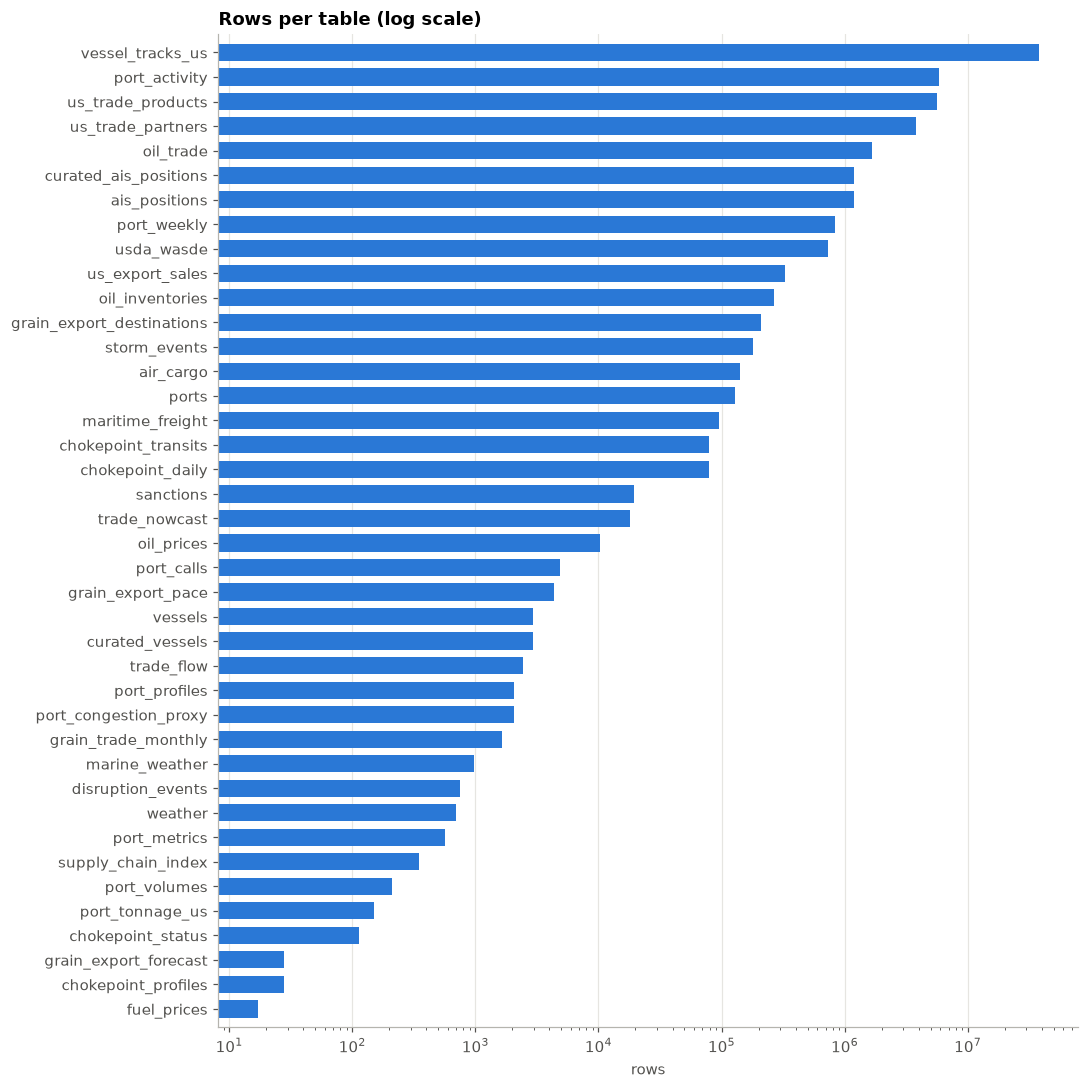

In [6]:
# Row counts span 8 to 38 million, so a log scale is the only way to see them all on one chart.
fig, ax = plt.subplots(figsize=(10, 10))
ordered = inventory.sort_values("num_rows")
ax.barh(ordered["table"], ordered["num_rows"], color=BLUE, height=0.7)
ax.set_xscale("log")
ax.set_title("Rows per table (log scale)")
ax.set_xlabel("rows")
ax.grid(axis="y", visible=False)
ax.margins(y=0.01)
plt.tight_layout()
plt.show()

### 1d. Register every table as a view

A **view** is a saved query, not a copy of the data. After this cell you can write `FROM port_activity`
instead of the long `hf://` path, and every query still reads only what it needs, live from Hugging Face.

> **Heads-up on `vessel_tracks_us`** (1 GB, 38M rows). Queries that touch only a few columns are fine,
> but `SELECT *` or `SUMMARIZE` on it will download most of the file. Stick to the smaller tables while learning.

In [7]:
for table in inventory["table"]:
    con.sql(f"CREATE OR REPLACE VIEW {table} AS SELECT * FROM '{BASE}/{table}/{table}.parquet'")

sql("SELECT table_name FROM information_schema.tables ORDER BY table_name").T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39
table_name,air_cargo,ais_positions,chokepoint_daily,chokepoint_profiles,chokepoint_status,chokepoint_transits,curated_ais_positions,curated_vessels,disruption_events,fuel_prices,grain_export_destinations,grain_export_forecast,grain_export_pace,grain_trade_monthly,marine_weather,maritime_freight,oil_inventories,oil_prices,oil_trade,port_activity,port_calls,port_congestion_proxy,port_metrics,port_profiles,port_tonnage_us,port_volumes,port_weekly,ports,sanctions,storm_events,supply_chain_index,trade_flow,trade_nowcast,us_export_sales,us_trade_partners,us_trade_products,usda_wasde,vessel_tracks_us,vessels,weather


## 2. Inspecting one table

Three questions to ask of any new table:

1. **What columns and types does it have?** → `DESCRIBE` (footer only, instant)
2. **What do rows look like?** → `SELECT * ... LIMIT 5`
3. **What's in each column?** → `SUMMARIZE`: min, max, distinct count, mean, quartiles and **% null** for every column

We'll use `port_weekly`: port calls per port per week, built from IMF PortWatch data.

In [8]:
sql("DESCRIBE port_weekly")

,column_name,column_type,null,key,default,extra
0,week_start,DATE,YES,None,None,None
1,port_id,VARCHAR,YES,None,None,None
2,port_name,VARCHAR,YES,None,None,None
3,country,VARCHAR,YES,None,None,None
4,iso3,VARCHAR,YES,None,None,None
5,days_reported,BIGINT,YES,None,None,None
6,is_complete_week,BOOLEAN,YES,None,None,None
7,portcalls,DOUBLE,YES,None,None,None
8,portcalls_container,DOUBLE,YES,None,None,None
9,portcalls_dry_bulk,DOUBLE,YES,None,None,None


In [9]:
sql("SELECT * FROM port_weekly WHERE port_name = 'Singapore' ORDER BY week_start DESC LIMIT 5")

,week_start,port_id,port_name,country,iso3,days_reported,is_complete_week,portcalls,portcalls_container,portcalls_dry_bulk,portcalls_general_cargo,portcalls_roro,portcalls_tanker,import_total,export_total
0,2026-09-28,port1201,Singapore,Singapore,SGP,5,False,593.00,174.00,8.00,38.00,18.00,355.00,"6,063,444.00","5,094,575.00"
1,2026-09-21,port1201,Singapore,Singapore,SGP,7,True,825.00,243.00,24.00,26.00,28.00,504.00,"7,191,653.00","7,348,540.00"
2,2026-09-14,port1201,Singapore,Singapore,SGP,7,True,783.00,233.00,15.00,34.00,18.00,483.00,"7,977,734.00","7,103,355.00"
3,2026-09-07,port1201,Singapore,Singapore,SGP,7,True,864.00,256.00,17.00,44.00,30.00,517.00,"7,810,368.00","8,615,506.00"
4,2026-08-31,port1201,Singapore,Singapore,SGP,7,True,833.00,248.00,14.00,37.00,23.00,511.00,"8,479,437.00","7,333,042.00"


`SUMMARIZE` reads the whole table, so use it on small and medium tables. Columns to look at first:

- **`null_percentage`**: how much is missing
- **`approx_unique`**: how many distinct values (1 means the column is constant; equal to the row count means it's an ID)
- **`min` / `max`**: impossible values (negative counts, dates in the future)
- **`q25` / `q50` / `q75`**: the quartiles. If the mean is far above the median (`q50`), the data is **skewed** by a few big values.

In [10]:
summary = sql("SUMMARIZE port_weekly")
summary[["column_name", "column_type", "min", "max", "approx_unique", "avg", "q50", "null_percentage"]]

,column_name,column_type,min,max,approx_unique,avg,q50,null_percentage
0,week_start,DATE,2018-12-31,2026-09-28,392,2022-11-14 00:00:00,2022-11-12,0.00
1,port_id,VARCHAR,fso0,port999,2295,NaN,NaN,0.00
2,port_name,VARCHAR,Aalborg,Årdalstangen,2345,NaN,NaN,0.00
3,country,VARCHAR,Albania,Yemen,159,NaN,NaN,0.00
4,iso3,VARCHAR,ABW,ZAF,206,NaN,NaN,0.00
5,days_reported,BIGINT,5,7,3,6.992592592592593,7,0.00
6,is_complete_week,BOOLEAN,false,true,2,NaN,NaN,0.00
7,portcalls,DOUBLE,0.0,1142.0,817,16.864641138313456,4.975367685913352,0.00
8,portcalls_container,DOUBLE,0.0,313.0,311,4.329692404268675,0.0,0.00
9,portcalls_dry_bulk,DOUBLE,0.0,420.0,268,2.636644845006427,0.0,0.00


Notice that the average `portcalls` is well above the median: most ports are small and a few are huge.
We'll come back to that in section 4.

### Sampling

For a quick look at a table too big to `SUMMARIZE`, take a random sample in SQL and use pandas'
`.describe()`. `USING SAMPLE` picks random rows. DuckDB still has to scan the columns you select, so
selecting fewer columns is what saves download time.

In [11]:
sample = sql('''
    SELECT portcalls, portcalls_container, portcalls_tanker, import_total, export_total
    FROM port_activity
    USING SAMPLE 100000 ROWS
''')
sample.describe(percentiles=[0.5, 0.9, 0.99])

,portcalls,portcalls_container,portcalls_tanker,import_total,export_total
count,"100,000.00","100,000.00","100,000.00","100,000.00","100,000.00"
mean,2.41,0.62,0.76,"15,740.12","15,837.13"
std,6.54,2.45,2.85,"69,950.54","71,435.67"
min,0.00,0.00,0.00,0.00,0.00
50%,1.00,0.00,0.00,0.00,0.00
90%,6.00,1.00,2.00,"34,495.90","30,940.10"
99%,28.00,11.00,10.00,"283,382.35","317,403.65"
max,163.00,48.00,98.00,"2,195,092.00","2,103,424.00"


## 3. Data quality checks

Do these before trusting any chart.

### 3a. Freshness: when was each table last updated?

Each table has its own date column, so we list them in a dictionary and build one `UNION ALL` query.

In [12]:
DATE_COLUMNS = {
    "port_activity": "activity_date",
    "port_weekly": "week_start",
    "chokepoint_daily": "transit_date",
    "ais_positions": "partition_date",
    "disruption_events": "partition_date",
    "us_trade_partners": "period_date",
    "us_trade_products": "period_date",
    "us_export_sales": "week_ending",
    "usda_wasde": "release_date",
    "oil_prices": "price_date",
    "oil_inventories": "report_date",
    "trade_nowcast": "month_date",
}

query = "\nUNION ALL\n".join(
    f"SELECT '{t}' AS table_name, min({c})::DATE AS first_date, max({c})::DATE AS last_date FROM {t}"
    for t, c in DATE_COLUMNS.items()
)
freshness = sql(query)
freshness["days_since_last"] = (pd.Timestamp.today().normalize() - pd.to_datetime(freshness["last_date"])).dt.days
freshness.sort_values("days_since_last")

,table_name,first_date,last_date,days_since_last
3,ais_positions,2026-07-30,2026-10-09,1
4,disruption_events,2026-09-28,2026-10-09,1
9,oil_prices,1986-01-02,2026-10-06,4
2,chokepoint_daily,2019-01-01,2026-10-04,6
10,oil_inventories,1982-08-20,2026-10-02,8
0,port_activity,2019-01-01,2026-10-02,8
7,us_export_sales,1999-06-03,2026-10-01,9
1,port_weekly,2018-12-31,2026-09-28,12
8,usda_wasde,2010-09-10,2026-09-11,29
5,us_trade_partners,2013-01-01,2026-08-01,70


Lags are expected to differ by source. PortWatch publishes weekly, Census trade data runs
about two months behind, and AIS positions are collected daily. A table falling far behind its usual lag
means a collector has stopped.

### 3b. Duplicates: is the natural key unique?

Every table has some combination of columns that *should* identify a row, such as one row per port per day.
If `count(*)` is bigger than the count of distinct keys, there are duplicates, and any sum will be inflated.

In [13]:
sql('''
    SELECT 'port_activity (date, port)' AS check_name,
           count(*) AS total_rows,
           count(DISTINCT (activity_date, port_id)) AS distinct_keys
    FROM port_activity
    UNION ALL
    SELECT 'chokepoint_daily (date, chokepoint)', count(*), count(DISTINCT (transit_date, chokepoint_id))
    FROM chokepoint_daily
    UNION ALL
    SELECT 'ais_positions (vessel, timestamp)', count(*), count(DISTINCT (mmsi, "timestamp"))
    FROM ais_positions
''').assign(duplicates=lambda d: d["total_rows"] - d["distinct_keys"])

,check_name,total_rows,distinct_keys,duplicates
0,"port_activity (date, port)",5848080,5848080,0
1,"chokepoint_daily (date, chokepoint)",79352,79352,0
2,"ais_positions (vessel, timestamp)",1194885,133490,1061395


`ais_positions` seems to have over 700,000 duplicates. Before deleting anything, find out **where** they come from.
Splitting by `source` and counting non-null values per column (`count(col)` skips NULLs, `count(*)` doesn't)
shows what each source actually provides:

In [14]:
sql('''
    SELECT source,
           count(*)           AS total_rows,
           count(mmsi)        AS has_mmsi,
           count(imo)         AS has_imo,
           count("timestamp") AS has_timestamp
    FROM ais_positions
    GROUP BY source
    ORDER BY total_rows DESC
''')

,source,total_rows,has_mmsi,has_imo,has_timestamp
0,axiomancer,1061096,0,1061096,0
1,tankermap,106336,106336,106336,106336
2,digitraffic,25593,25593,22700,25593
3,aisstream,1860,1860,0,1860


One source (`axiomancer`) provides no MMSI and no timestamp at all, only an IMO number and the snapshot date.
For those rows, the key `(mmsi, timestamp)` is `(NULL, NULL)` every time, so they all look like the same row.
They aren't real duplicates. The lesson: **a duplicate check is only as good as its key**, and NULLs in a key
column break it. A better key for this table is `(coalesce(imo, mmsi), partition_date, source)`.

### 3c. Messy category labels

Data from several sources often labels the same thing differently. Two examples in this dataset:

In [15]:
# AIS vessel types: some sources say "tanker", others "Crude Oil Tanker" or "LNG Tanker",
# and one (digitraffic) sends the raw AIS ship-type number: 70-79 = cargo, 80-89 = tanker, 60s = passenger...
sql("SELECT vessel_type, count(*) AS n FROM ais_positions GROUP BY vessel_type ORDER BY n DESC")

,vessel_type,n
0,bulk_carrier,430291
1,other,304782
2,tanker,202693
3,general_cargo,48328
4,Crude Oil Tanker,46695
5,container,41051
6,Chemical/Oil Products Tanker,35793
7,LNG Tanker,12610
8,Oil Products Tanker,11195
9,cargo,8410


In [16]:
# GDACS alert levels: "Red" and "RED" (or "Orange" and "ORANGE") are the same level,
# but GROUP BY treats them as different. The collector has upper-cased them since
# 2026-10-10, so this reads the dataset as it was on 2026-10-09: HF keeps every commit,
# and `@<commit>` in the path picks one.
OLD = f"hf://datasets/{REPO_ID}@9d1bdcc715"
sql(f'''
    SELECT alert_level, count(*) AS n
    FROM '{OLD}/disruption_events/disruption_events.parquet'
    GROUP BY alert_level
    ORDER BY n DESC
''')

,alert_level,n
0,Orange,478
1,Red,146
2,RED,131
3,ORANGE,1


The fix is to normalize before grouping, e.g. `GROUP BY upper(alert_level)`, or, better, once at the source,
which is what the collector now does. Two sources of the same events (the PortWatch disruptions layer and GeoPulse) spelled it differently. Section 6 does the same for
vessel types with a `CASE WHEN`.

## 4. Port activity

`port_activity` has daily port calls (ships arriving) for about 2,000 ports since 2019, split by vessel type.
`port_weekly` is the same data rolled up to Monday–Sunday weeks.

### 4a. Global port calls over time

We let DuckDB add up all ports per week (834K rows → about 400), then plot.
Weeks are filtered to `is_complete_week` so a partly-reported final week doesn't look like a crash.

In [17]:
weekly = sql('''
    SELECT week_start,
           sum(portcalls)               AS total,
           sum(portcalls_container)     AS container,
           sum(portcalls_dry_bulk)      AS dry_bulk,
           sum(portcalls_tanker)        AS tanker,
           sum(portcalls_general_cargo) AS general_cargo,
           sum(portcalls_roro)          AS roro
    FROM port_weekly
    WHERE is_complete_week
    GROUP BY week_start
    ORDER BY week_start
''')
weekly["week_start"] = pd.to_datetime(weekly["week_start"])
weekly = weekly.set_index("week_start")
weekly.tail()

,total,container,dry_bulk,tanker,general_cargo,roro
week_start,,,,,,
2026-08-24,"32,879.00","8,404.00","4,955.00","10,373.00","7,195.00","1,952.00"
2026-08-31,"33,116.00","8,516.00","5,041.00","10,505.00","7,172.00","1,882.00"
2026-09-07,"33,333.00","8,514.00","5,039.00","10,640.00","7,160.00","1,980.00"
2026-09-14,"33,067.00","8,584.00","5,067.00","10,474.00","7,036.00","1,906.00"
2026-09-21,"33,106.00","8,575.00","5,042.00","10,582.00","6,995.00","1,912.00"


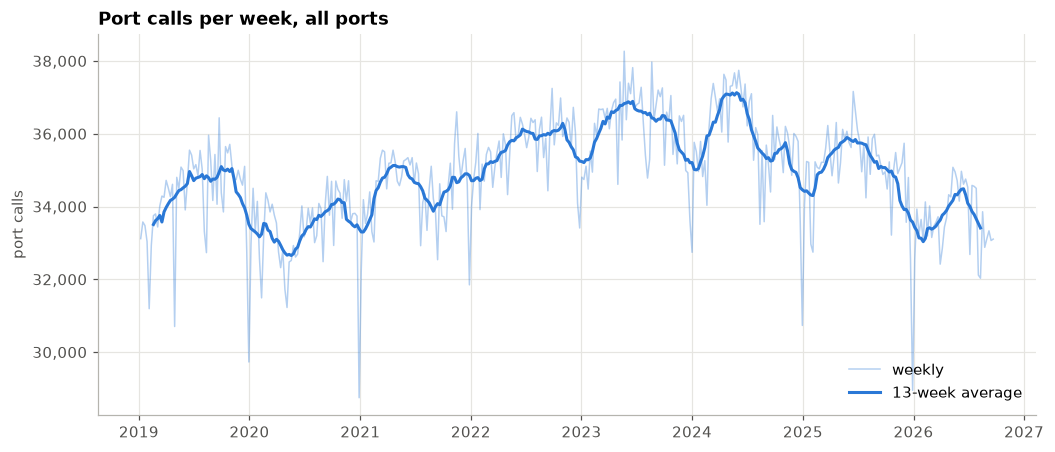

In [18]:
fig, ax = plt.subplots()
ax.plot(weekly.index, weekly["total"], color=BLUE, alpha=0.35, linewidth=1, label="weekly")
# A rolling mean smooths out week-to-week noise. 13 weeks is about one quarter.
ax.plot(weekly.index, weekly["total"].rolling(13, center=True).mean(), color=BLUE, linewidth=2, label="13-week average")
ax.yaxis.set_major_formatter(thousands)
ax.set_title("Port calls per week, all ports")
ax.set_ylabel("port calls")
ax.legend(loc="lower right")
plt.show()

### 4b. Mix by vessel type

A stacked area shows how the total splits by vessel type over time. A **stacked** chart answers
"what share is each part?"; separate lines answer "how did each part change?".

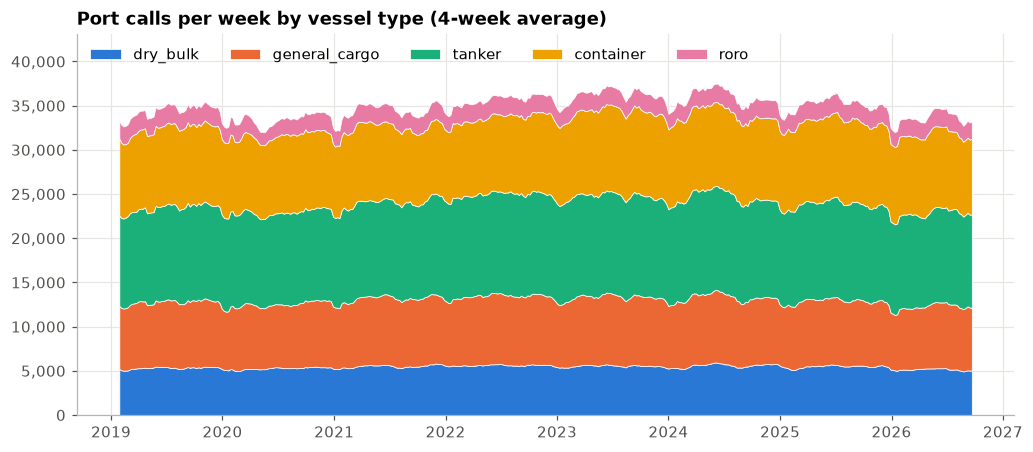

Share of all port calls since 2019 (%):
tanker          31.40
container       25.70
general_cargo   21.50
dry_bulk        15.60
roro             5.70


In [19]:
types = ["dry_bulk", "general_cargo", "tanker", "container", "roro"]
smoothed = weekly[types].rolling(4).mean().dropna()

fig, ax = plt.subplots()
ax.stackplot(smoothed.index, [smoothed[t] for t in types], labels=types,
             colors=PALETTE[: len(types)], edgecolor="white", linewidth=0.5)
ax.yaxis.set_major_formatter(thousands)
ax.set_title("Port calls per week by vessel type (4-week average)")
ax.legend(loc="upper left", ncols=5)
ax.set_ylim(0, smoothed.sum(axis=1).max() * 1.15)  # headroom for the legend
plt.show()

share = (weekly[types].sum() / weekly[types].sum().sum() * 100).round(1)
print("Share of all port calls since 2019 (%):")
print(share.sort_values(ascending=False).to_string())

### 4c. Busiest ports in the last 52 weeks

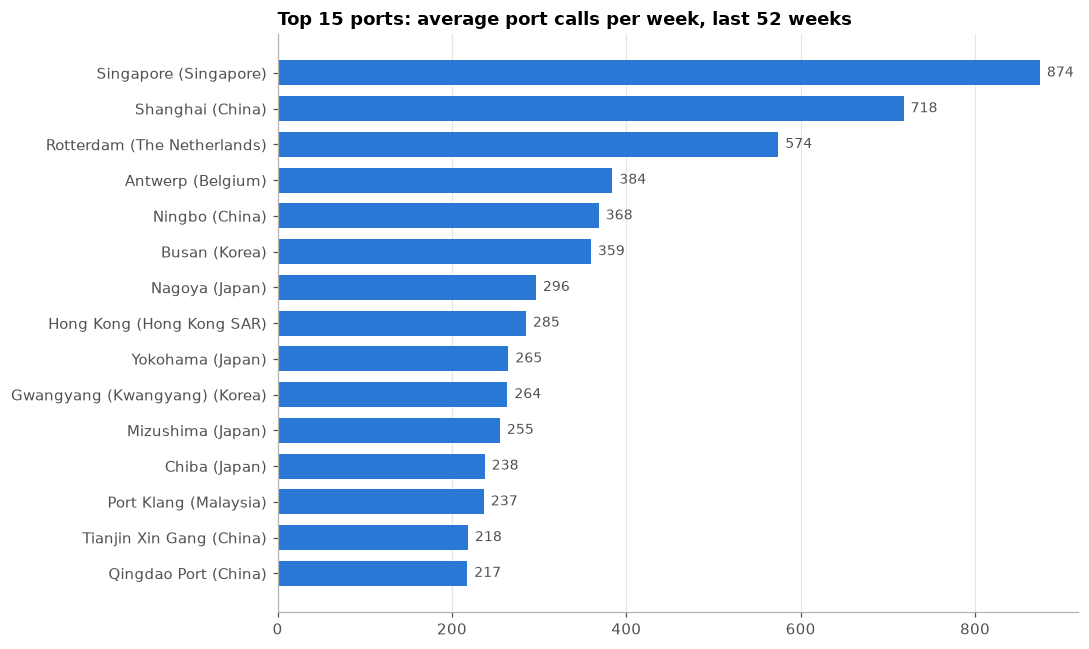

In [20]:
top_ports = sql('''
    SELECT port_name || ' (' || country || ')' AS port,
           avg(portcalls) AS avg_weekly_calls
    FROM port_weekly
    WHERE is_complete_week
      AND week_start >= (SELECT max(week_start) FROM port_weekly) - INTERVAL 52 WEEK
    GROUP BY ALL
    ORDER BY avg_weekly_calls DESC
    LIMIT 15
''')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_ports["port"][::-1], top_ports["avg_weekly_calls"][::-1], color=BLUE, height=0.7)
for y, v in enumerate(top_ports["avg_weekly_calls"][::-1]):
    ax.text(v + 8, y, f"{v:,.0f}", va="center", fontsize=9, color=MUTED)
ax.set_title("Top 15 ports: average port calls per week, last 52 weeks")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

### 4d. Seasonality: average daily port calls by month and year

A heatmap of year × month shows seasonal patterns and unusual years at a glance.
`date_trunc('month', ...)` rounds each date down to the first of its month. We first total per day,
then average the days in each month, so months with 31 days aren't favored over February.

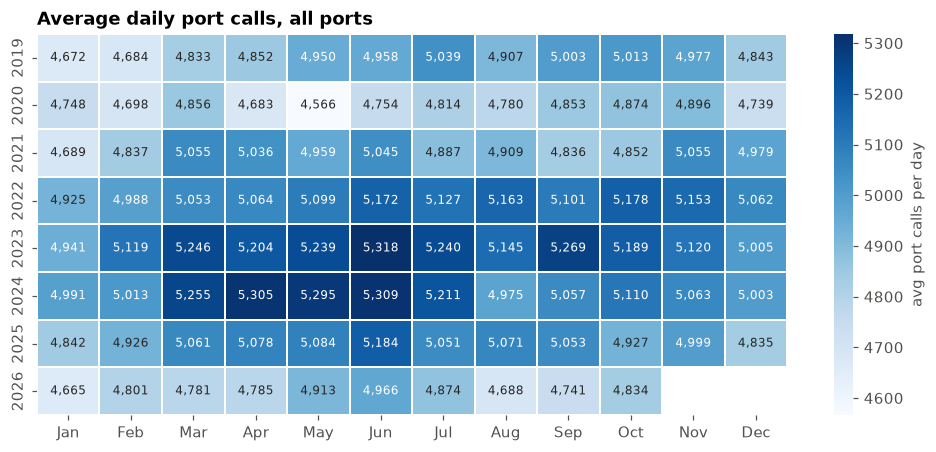

In [21]:
monthly = sql('''
    WITH daily AS (
        SELECT activity_date, sum(portcalls) AS calls
        FROM port_activity
        GROUP BY activity_date
    )
    SELECT year(activity_date) AS year, month(activity_date) AS month, avg(calls) AS avg_daily_calls
    FROM daily
    GROUP BY ALL
''')
# pivot: rows = year, columns = month, values = average
grid = monthly.pivot(index="year", columns="month", values="avg_daily_calls")

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.heatmap(grid, cmap="Blues", annot=True, fmt=",.0f", annot_kws={"fontsize": 8},
            linewidths=1, linecolor="white", cbar_kws={"label": "avg port calls per day"}, ax=ax)
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.set_title("Average daily port calls, all ports")
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(False)
plt.show()

Things to look for: January is the quietest month in most years, and spring/early summer the busiest.
April–June 2020 shows the COVID slowdown, and 2023–2024 were the busiest years.
Empty cells are months not yet published, and the latest month may be partial.

### 4e. Most ports are small: a skewed distribution

Comparing the **mean** with the **median** is the quickest skew check. On a normal (linear) axis
almost every port piles up in the first bar, so we use log-spaced bins.

2,065 ports | mean 16.7 | median 5.0 calls per week
Left out of the chart: 142 ports averaging under 0.1 calls per week


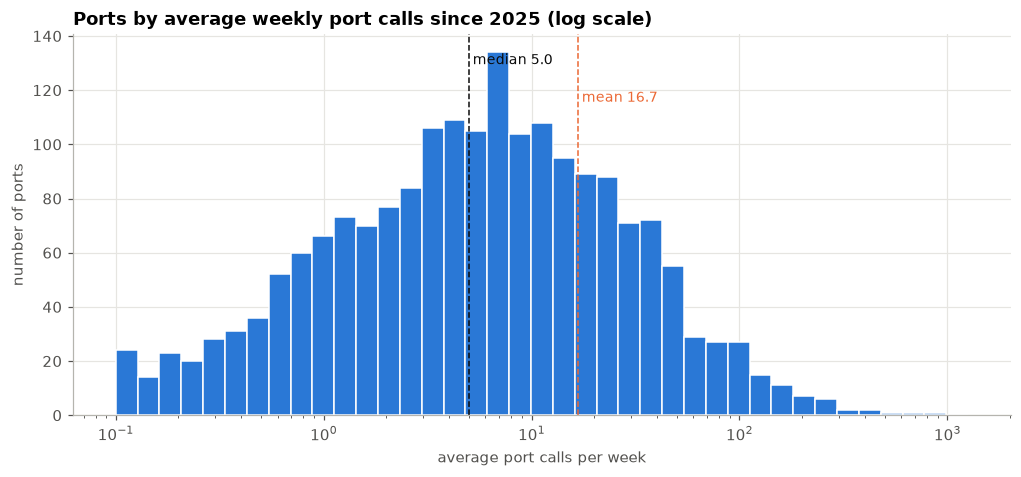

The busiest 10% of ports handle 59% of all port calls.


In [22]:
import numpy as np

per_port = sql('''
    SELECT port_id, avg(portcalls) AS avg_weekly_calls
    FROM port_weekly
    WHERE is_complete_week AND week_start >= DATE '2025-01-01'
    GROUP BY port_id
''')
mean, median = per_port["avg_weekly_calls"].mean(), per_port["avg_weekly_calls"].median()
print(f"{len(per_port):,} ports | mean {mean:.1f} | median {median:.1f} calls per week")

# A log axis can't show 0, so leave out ports with (almost) no calls and say how many there were.
tiny = per_port["avg_weekly_calls"] < 0.1
print(f"Left out of the chart: {tiny.sum()} ports averaging under 0.1 calls per week")

fig, ax = plt.subplots()
bins = np.logspace(-1, 3.1, 40)
ax.hist(per_port.loc[~tiny, "avg_weekly_calls"], bins=bins, color=BLUE, edgecolor="white")
ax.set_xscale("log")
ax.axvline(median, color=INK, linestyle="--", linewidth=1)
ax.axvline(mean, color=ORANGE, linestyle="--", linewidth=1)
ax.text(median, ax.get_ylim()[1] * 0.95, f" median {median:.1f}", color=INK, fontsize=9, va="top")
ax.text(mean, ax.get_ylim()[1] * 0.85, f" mean {mean:.1f}", color=ORANGE, fontsize=9, va="top")
ax.set_title("Ports by average weekly port calls since 2025 (log scale)")
ax.set_xlabel("average port calls per week")
ax.set_ylabel("number of ports")
plt.show()

top10_share = per_port["avg_weekly_calls"].nlargest(int(len(per_port) * 0.10)).sum() / per_port["avg_weekly_calls"].sum()
print(f"The busiest 10% of ports handle {top10_share:.0%} of all port calls.")

### 4f. A map of the ports

`port_profiles` has each port's latitude and longitude. A scatter plot of longitude (x) against
latitude (y) is a basic map. The coastlines show up on their own because that's where the ports are.
Dot size is the number of vessels that use the port.

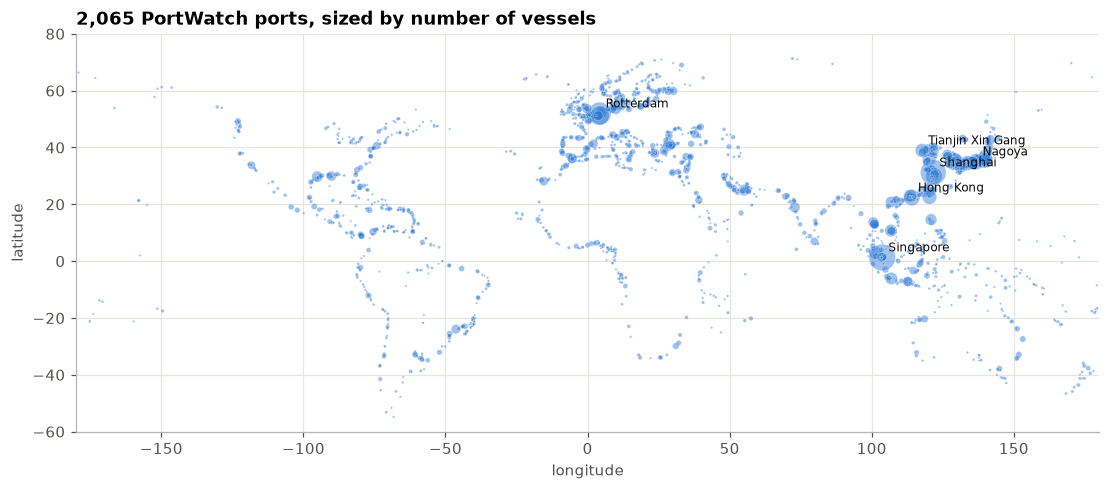

In [23]:
profiles = sql('''
    SELECT port_name, country, latitude, longitude, vessel_count_total
    FROM port_profiles
    WHERE latitude IS NOT NULL
''')

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(profiles["longitude"], profiles["latitude"],
           s=profiles["vessel_count_total"] / profiles["vessel_count_total"].max() * 300 + 2,
           color=BLUE, alpha=0.45, edgecolor="white", linewidth=0.3)
# Label the biggest ports, skipping any too close to one already labeled so names don't overlap.
labeled = []
for _, r in profiles.nlargest(15, "vessel_count_total").iterrows():
    if all(abs(r["longitude"] - x) > 10 or abs(r["latitude"] - y) > 6 for x, y in labeled):
        ax.annotate(r["port_name"], (r["longitude"], r["latitude"]), fontsize=8, color=INK,
                    xytext=(4, 4), textcoords="offset points")
        labeled.append((r["longitude"], r["latitude"]))
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 80)
ax.set_aspect("equal")
ax.set_title(f"{len(profiles):,} PortWatch ports, sized by number of vessels")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
plt.show()

## 5. Chokepoints

`chokepoint_daily` counts vessels passing 28 narrow sea lanes (Suez, Panama, Hormuz...) every day,
with ready-made 7-day averages (`n_total_7d`) and comparisons to a year earlier.

### 5a. Before and after an event: the Red Sea crisis

From November 2023, attacks on ships near Yemen pushed many vessels to avoid the Red Sea
and go around Africa instead. If that's true, the data should show Suez and Bab el-Mandeb traffic
falling while Cape of Good Hope traffic rises, all at the same time.

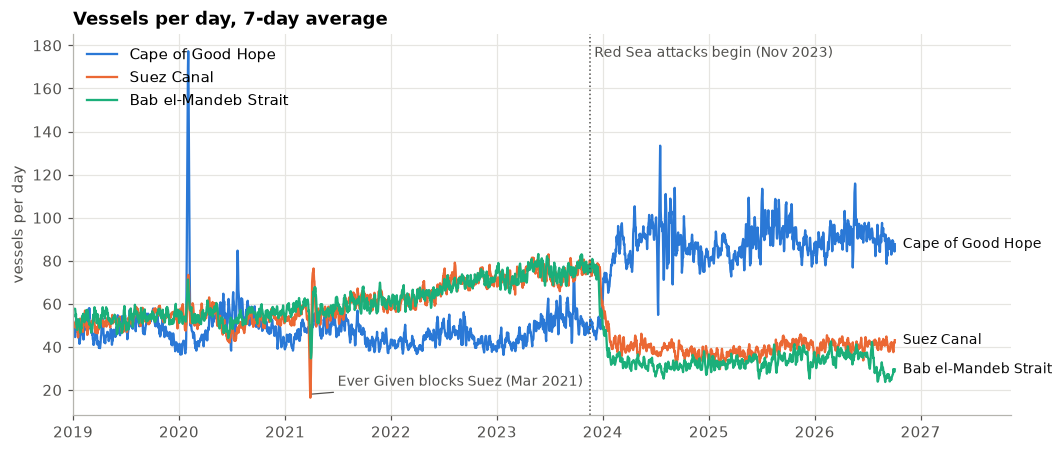

In [24]:
red_sea = sql('''
    SELECT transit_date, chokepoint_name, n_total_7d
    FROM chokepoint_daily
    WHERE chokepoint_name IN ('Suez Canal', 'Bab el-Mandeb Strait', 'Cape of Good Hope')
    ORDER BY transit_date
''')
red_sea["transit_date"] = pd.to_datetime(red_sea["transit_date"])
# Long format (one row per date per chokepoint) -> wide format (one column per chokepoint), for plotting.
wide = red_sea.pivot(index="transit_date", columns="chokepoint_name", values="n_total_7d")

fig, ax = plt.subplots()
for name, color in zip(["Cape of Good Hope", "Suez Canal", "Bab el-Mandeb Strait"], PALETTE):
    ax.plot(wide.index, wide[name], color=color, label=name)
    ax.text(wide.index[-1], wide[name].iloc[-1], f"  {name}", color=INK, fontsize=9, va="center")
event = pd.Timestamp("2023-11-19")
ax.axvline(event, color=MUTED, linestyle=":", linewidth=1)
ax.text(event, ax.get_ylim()[1] * 0.97, " Red Sea attacks begin (Nov 2023)", color=MUTED, fontsize=9, va="top")
ax.annotate("Ever Given blocks Suez (Mar 2021)", xy=(pd.Timestamp("2021-03-25"), 18),
            xytext=(pd.Timestamp("2021-07-01"), 22), fontsize=9, color=MUTED,
            arrowprops={"arrowstyle": "-", "color": MUTED, "linewidth": 0.8})
ax.set_title("Vessels per day, 7-day average")
ax.set_ylabel("vessels per day")
ax.legend(loc="upper left")
ax.set_xlim(wide.index[0], wide.index[-1] + pd.Timedelta(days=400))  # room for line-end labels
plt.show()

In [25]:
# Put numbers on it: average daily transits in the year before vs the year after.
red_sea["period"] = np.where(red_sea["transit_date"] < event, "year before", "year after")
in_window = red_sea["transit_date"].between(event - pd.Timedelta(days=365), event + pd.Timedelta(days=365))
before_after = red_sea[in_window].pivot_table(index="chokepoint_name", columns="period", values="n_total_7d", aggfunc="mean")
before_after = before_after[["year before", "year after"]]
before_after["change_%"] = (before_after["year after"] / before_after["year before"] - 1) * 100
before_after

period,year before,year after,change_%
chokepoint_name,,,
Bab el-Mandeb Strait,74.27,37.19,-49.93
Cape of Good Hope,47.85,83.18,73.84
Suez Canal,73.50,44.29,-39.73


### 5b. Small multiples: every major chokepoint at once

When there are many series on very different scales, one chart per series (**small multiples**)
works better than one crowded chart. `sharey=False` lets each panel use its own y-axis.

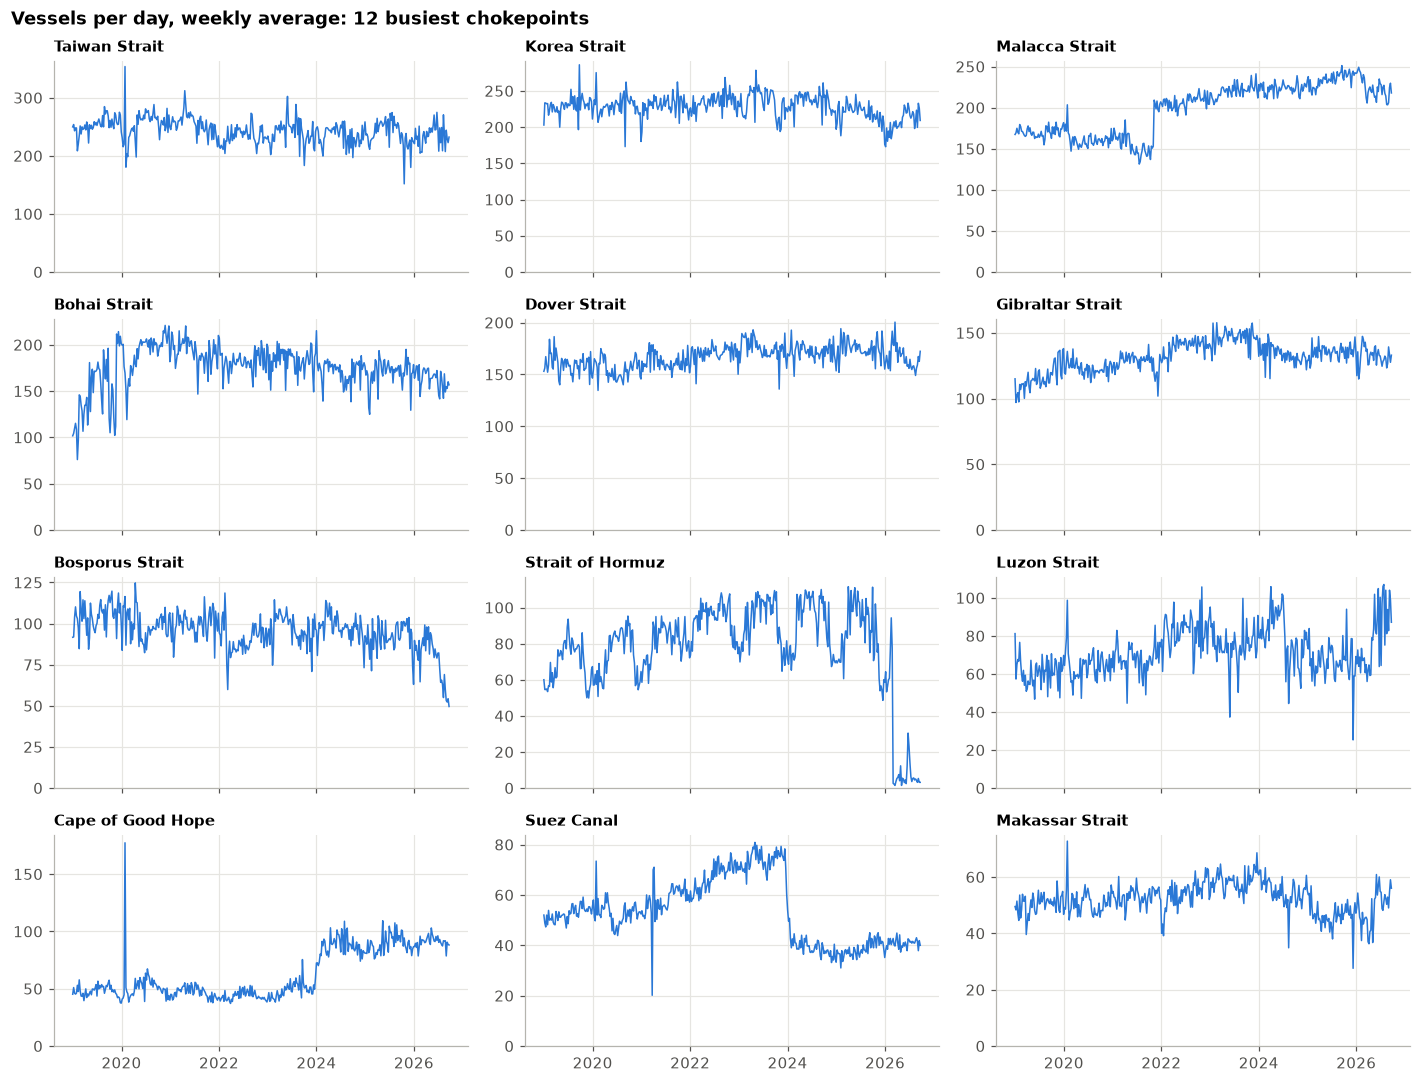

In [26]:
choke = sql('''
    SELECT date_trunc('week', transit_date) AS week, chokepoint_name, avg(n_total) AS vessels_per_day
    FROM chokepoint_daily
    GROUP BY ALL
''')
choke["week"] = pd.to_datetime(choke["week"])
choke_wide = choke.pivot(index="week", columns="chokepoint_name", values="vessels_per_day").iloc[:-1]  # drop partial last week

busiest = choke_wide.mean().nlargest(12).index
fig, axes = plt.subplots(4, 3, figsize=(13, 10), sharex=True)
for ax, name in zip(axes.flat, busiest):
    ax.plot(choke_wide.index, choke_wide[name], color=BLUE, linewidth=1)
    ax.set_title(name, fontsize=10)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("Vessels per day, weekly average: 12 busiest chokepoints", x=0.01, ha="left", fontweight="bold")
plt.tight_layout()
plt.show()

Small multiples make odd things easy to spot. Each one needs checking before you trust it:

- **Strait of Hormuz** falls from 60–90 vessels a day to under 10 from early March 2026, and stays there.
  A drop that large is either a major real-world event or a data problem. Section 5d works through how to tell
  which (it's real).
- **Malacca Strait** jumps by about 50 vessels a day in late 2021 and stays at the new level. A sudden, permanent
  step like that often comes from a change in how the data is made, not in the world.
- **Cape of Good Hope** spikes to roughly 3× normal for one week in January 2020, then goes straight back.
  It looks like a data glitch. Section 5c shows how one week like that can mislead a statistic.

### 5c. Which chokepoints move together?

A correlation matrix shows which series rise and fall together (+1), opposite (−1), or unrelated (0).

**Correlate changes, not levels.** Any two series that both trend upward will look correlated even if
they have nothing to do with each other. Week-over-week **% changes** (`pct_change()`) remove the trend,
so what's left is "when one has an unusual week, does the other too?"

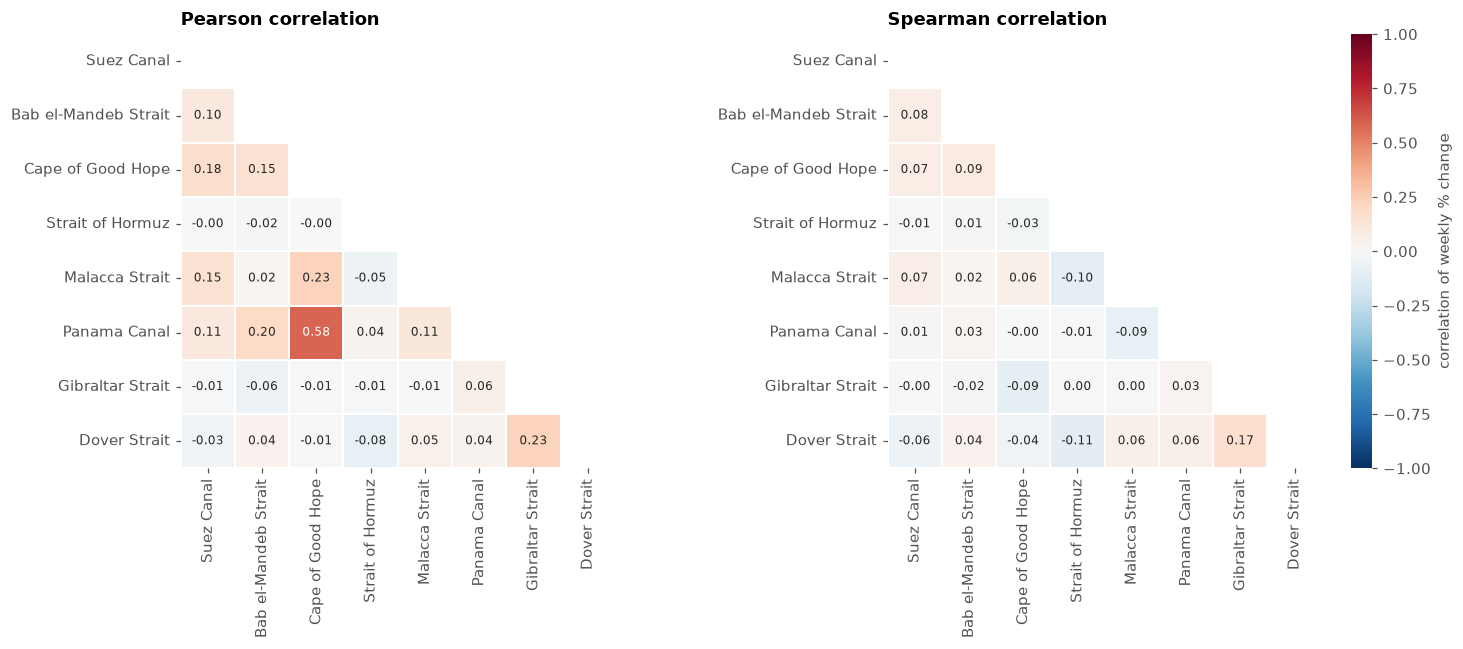

In [27]:
picks = ["Suez Canal", "Bab el-Mandeb Strait", "Cape of Good Hope", "Strait of Hormuz",
         "Malacca Strait", "Panama Canal", "Gibraltar Strait", "Dover Strait"]
changes = choke_wide[picks].pct_change().dropna()

# Two kinds of correlation, side by side:
#   pearson  (the default) uses the actual values, so one extreme week can dominate it
#   spearman uses each week's *rank* instead, so one extreme week counts no more than any other
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, method in zip(axes, ["pearson", "spearman"]):
    corr = changes.corr(method=method)
    mask = np.triu(np.ones_like(corr, dtype=bool))  # hide the duplicate upper half
    sns.heatmap(corr, mask=mask, cmap="RdBu_r", vmin=-1, vmax=1, center=0, annot=True, fmt=".2f",
                annot_kws={"fontsize": 8}, linewidths=1, linecolor="white", square=True, ax=ax,
                cbar=method == "spearman", cbar_kws={"label": "correlation of weekly % change"})
    ax.set_title(f"{method.title()} correlation")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(False)
plt.tight_layout()
plt.show()

The two methods disagree on **Cape of Good Hope vs Panama Canal**: about 0.6 by Pearson, about 0 by Spearman.
When that happens, look for the rows driving it:

In [28]:
# The weeks with the biggest moves at both chokepoints at once
pair = changes[["Cape of Good Hope", "Panama Canal"]]
biggest = pair.assign(combined=pair.abs().sum(axis=1)).nlargest(5, "combined")

# Re-compute Pearson without the two most extreme weeks (the spike and the bounce back)
r_all = pair["Cape of Good Hope"].corr(pair["Panama Canal"])
trimmed = pair.drop(index=biggest.index[:2])
r_trim = trimmed["Cape of Good Hope"].corr(trimmed["Panama Canal"])
print(f"Pearson, all {len(pair)} weeks: {r_all:.2f} | without the 2 most extreme weeks: {r_trim:.2f}")
biggest

Pearson, all 403 weeks: 0.58 | without the 2 most extreme weeks: -0.01


chokepoint_name,Cape of Good Hope,Panama Canal,combined
week,,,
2020-01-27,2.96,1.41,4.37
2020-02-03,-0.71,-0.64,1.35
2023-09-18,0.80,0.00,0.80
2020-06-29,0.64,0.06,0.69
2024-07-29,0.36,-0.15,0.51


One week (late January 2020, the Cape spike from 5b) shows +296% at the Cape and +141% at Panama at the same time.
It's probably a data glitch. Drop it and the bounce back the following week, and the 0.6 disappears.

Overall, weekly changes at different chokepoints are mostly unrelated (Spearman near 0), even for Suez and
Bab el-Mandeb at either end of the Red Sea. Weekly counts are noisy, and the Red Sea shift in 5a
shows up in the long-run *level*, not in week-to-week changes.

**Takeaways:** a correlation can come from a single bad row. Use Spearman, or look at a scatter plot, before
you believe a Pearson number.

### 5d. Is a surprise real? The 2026 Hormuz closure

Section 5b showed Strait of Hormuz traffic collapsing in March 2026. Before you explain, delete or model
a surprise like that, decide whether it happened in the world or only in the data. Three checks, from cheapest up:

1. **Look at it closely.** A data problem often hits one column, one source or one day. A real shock hits everything at once.
2. **Find independent data that should move too.** If the strait closed, ports *inside* the Gulf should go quiet,
   ports *outside* it shouldn't, and oil prices should jump.
3. **Check the news** for a dated event that matches.

**Check 1: the days around the drop, by vessel type**

In [29]:
sql('''
    SELECT transit_date, n_total, n_tanker, n_container, n_dry_bulk
    FROM chokepoint_daily
    WHERE chokepoint_name = 'Strait of Hormuz'
      AND transit_date BETWEEN DATE '2026-02-24' AND DATE '2026-03-07'
    ORDER BY transit_date
''')

,transit_date,n_total,n_tanker,n_container,n_dry_bulk
0,2026-02-24,93,49,15,19
1,2026-02-25,116,59,31,17
2,2026-02-26,89,45,15,12
3,2026-02-27,64,37,5,15
4,2026-02-28,57,36,5,11
5,2026-03-01,20,5,3,9
6,2026-03-02,4,1,0,3
7,2026-03-03,4,1,1,2
8,2026-03-04,0,0,0,0
9,2026-03-05,3,1,0,1


Every vessel type falls together, from about 90 a day to 2–4 within two days. That's what a real closure looks like.
A broken feed would more likely show one type vanishing, or exact zeros on every day.

**Check 2: ports inside vs. outside the strait**

Ships for Qatar, Kuwait, Bahrain, Iraq and most UAE and Saudi Gulf ports *must* pass Hormuz. Oman, the UAE's east
coast and Saudi Arabia's Red Sea ports don't. `port_profiles` has each port's longitude, which splits the UAE and
Saudi Arabia into their two coasts. This is a **join**: `port_weekly` has the port calls, `port_profiles` the location,
and `USING (port_id)` matches them up.

In [30]:
gulf = sql('''
    SELECT date_trunc('month', w.week_start) AS month,
           CASE
               WHEN w.iso3 IN ('QAT', 'KWT', 'BHR', 'IRQ')       THEN 'inside: Qatar, Kuwait, Bahrain, Iraq'
               WHEN w.iso3 = 'ARE' AND p.longitude < 56          THEN 'inside: UAE Gulf coast'
               WHEN w.iso3 = 'SAU' AND p.longitude >= 45         THEN 'inside: Saudi Gulf coast'
               WHEN w.iso3 = 'OMN'                               THEN 'outside: Oman'
               WHEN w.iso3 = 'SAU' AND p.longitude < 45          THEN 'outside: Saudi Red Sea coast'
           END AS area,
           sum(w.portcalls) / count(DISTINCT w.week_start) AS calls_per_week
    FROM port_weekly AS w
    JOIN port_profiles AS p USING (port_id)
    WHERE w.is_complete_week
      AND w.week_start >= DATE '2025-10-01'
      AND w.iso3 IN ('QAT', 'KWT', 'BHR', 'IRQ', 'ARE', 'SAU', 'OMN')
    -- Name the groups explicitly: GROUP BY ALL would group by the columns *inside* the CASE
    -- (iso3, longitude), giving one row per port instead of one per area.
    GROUP BY month, area
    HAVING area IS NOT NULL
''')
gulf.pivot(index="month", columns="area", values="calls_per_week").round(0)

area,"inside: Qatar, Kuwait, Bahrain, Iraq",inside: Saudi Gulf coast,inside: UAE Gulf coast,outside: Oman,outside: Saudi Red Sea coast
month,,,,,
2025-10-01,233.00,132.00,441.00,92.00,106.00
2025-11-01,215.00,125.00,433.00,82.00,110.00
2025-12-01,191.00,108.00,397.00,73.00,95.00
2026-01-01,203.00,119.00,412.00,79.00,100.00
2026-02-01,232.00,133.00,434.00,81.00,108.00
2026-03-01,68.00,56.00,90.00,63.00,119.00
2026-04-01,58.00,38.00,115.00,91.00,148.00
2026-05-01,51.00,28.00,88.00,95.00,166.00
2026-06-01,76.00,34.00,156.00,96.00,150.00


Ports inside the Gulf lose 60–80% of their traffic from March. Oman dips in March, then ends up busier than before,
and Saudi Arabia's Red Sea ports get *busier*, presumably as Saudi oil and goods head west to avoid the strait. Some traffic inside the Gulf
continues, but it's mostly ships moving between Gulf ports.

Brent crude (section 9) is a third independent check: about $71 in late February, $85 the first week of March,
and $124 by April.

**Check 3: a dated event.** Iran closed the strait on 28 February 2026, after US and Israeli strikes on Tehran.
The chart below marks the main events against the traffic data.

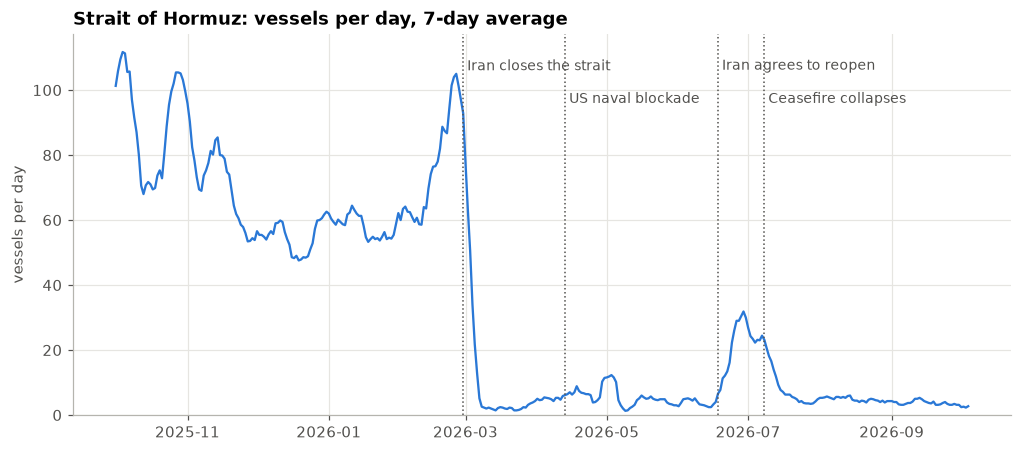

In [31]:
hz = sql('''
    SELECT transit_date, n_total_7d
    FROM chokepoint_daily
    WHERE chokepoint_name = 'Strait of Hormuz' AND transit_date >= DATE '2025-10-01'
    ORDER BY transit_date
''')
hz["transit_date"] = pd.to_datetime(hz["transit_date"])

EVENTS = {  # date: label (sources in the text below)
    "2026-02-28": "Iran closes the strait",
    "2026-04-13": "US naval blockade",
    "2026-06-18": "Iran agrees to reopen",
    "2026-07-08": "Ceasefire collapses",
}

fig, ax = plt.subplots()
ax.plot(hz["transit_date"], hz["n_total_7d"], color=BLUE)
top = hz["n_total_7d"].max()
for i, (day, label) in enumerate(EVENTS.items()):
    d = pd.Timestamp(day)
    ax.axvline(d, color=MUTED, linestyle=":", linewidth=1)
    # Stagger label heights so neighbouring labels don't overlap
    ax.text(d, top * (0.98 - 0.09 * (i % 2)), f" {label}", color=MUTED, fontsize=9, va="top")
ax.set_ylim(0, top * 1.05)
ax.set_title("Strait of Hormuz: vessels per day, 7-day average")
ax.set_ylabel("vessels per day")
plt.show()

The data follows the events: the collapse on 28 February, a short rebound to about 30 a day after Iran agreed to
reopen in mid-June, and a return to near zero once the ceasefire collapsed in July.

**Verdict: real.** Keep these rows, and don't let a cleaning step treat them as outliers. Two cautions when using them:

- **The counts are a floor.** PortWatch counts ships from their AIS radio signals, and during the closure some tankers
  crossed with AIS switched off ("dark"). True traffic was probably somewhat higher than 3–5 a day.
- **The dataset has no table for events like this.** `disruption_events` covers natural hazards only (earthquakes,
  storms, floods), so it can't explain a war or a blockade. Bring that context in yourself, as done here.

Sources: [2026 Strait of Hormuz campaign (Wikipedia)](https://en.wikipedia.org/wiki/2026_Strait_of_Hormuz_campaign) ·
[CNBC, 2 Mar 2026](https://www.cnbc.com/2026/03/02/strait-of-hormuz-crisis-us-iran-israel-war-shipping-trade-oil.html) ·
[Bloomberg, 3 Aug 2026: tankers crossing dark](https://www.bloomberg.com/news/articles/2026-08-03/saudi-s-yanbu-port-bustles-as-more-tankers-cross-chokepoint-dark)

## 6. AIS vessel positions

`ais_positions` holds daily snapshots of ship positions (from the AIS radio beacons ships broadcast):
location, speed over ground (`sog`, knots), heading, destination. Collection started in mid-2026.

### 6a. Clean up vessel types with `CASE WHEN`

Section 3c showed the labels are inconsistent. `CASE WHEN` maps them into a few clean groups.
`ILIKE` is a case-insensitive pattern match where `%` means "anything". `regexp_full_match` checks
a regular expression: `'8[0-9]'` means "an 8 followed by one digit", i.e. the numeric AIS tanker codes 80–89.
The first `WHEN` that matches wins, so order matters.

Section 3b showed some sources have no MMSI, so vessels are counted by `coalesce(imo, mmsi)`:
the IMO number if there is one, otherwise the MMSI.

In [32]:
VESSEL_GROUP = '''
    CASE
        WHEN vessel_type ILIKE '%tanker%' OR vessel_type ILIKE '%lng%'
             OR regexp_full_match(vessel_type, '8[0-9]')                  THEN 'tanker'
        WHEN vessel_type ILIKE '%bulk%'                                    THEN 'bulk carrier'
        WHEN vessel_type ILIKE '%container%'                               THEN 'container'
        WHEN vessel_type ILIKE '%cargo%' OR regexp_full_match(vessel_type, '7[0-9]') THEN 'other cargo'
        ELSE 'other'
    END
'''

groups = sql(f'''
    SELECT {VESSEL_GROUP} AS vessel_group,
           count(DISTINCT coalesce(imo, mmsi)) AS vessels,
           count(*) AS position_reports
    FROM ais_positions
    GROUP BY ALL
    ORDER BY vessels DESC
''')
groups

,vessel_group,vessels,position_reports
0,bulk carrier,26278,430291
1,other,23021,336675
2,tanker,13651,322319
3,other cargo,4956,64549
4,container,2424,41051


### 6b. Speed: moving vs. stopped

Ships are either at anchor/berth (speed near 0) or sailing (10–15 knots), with little in between.
A histogram shows that **two-peaked** (bimodal) shape. An average speed would land in the empty middle
and describe almost no real ship, which is a good reason to plot a distribution before reporting a mean.

Share of reports under 0.5 knots (stationary): 41%
Mean speed 6.2 kn vs median 5.9 kn


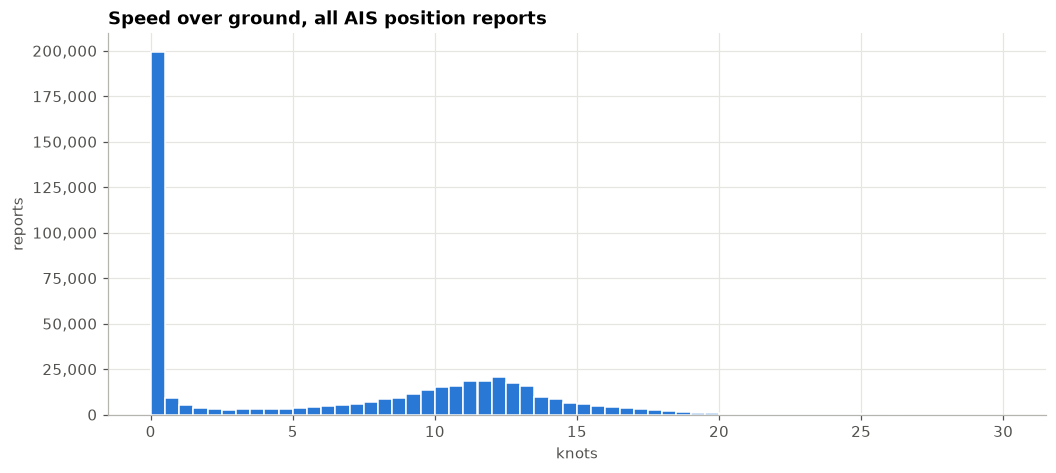

In [33]:
speeds = sql(f'''
    SELECT {VESSEL_GROUP} AS vessel_group, sog
    FROM ais_positions
    WHERE sog BETWEEN 0 AND 30   -- AIS uses 102.3 to mean "not available"; drop impossible values
''')
print(f"Share of reports under 0.5 knots (stationary): {(speeds['sog'] < 0.5).mean():.0%}")
print(f"Mean speed {speeds['sog'].mean():.1f} kn vs median {speeds['sog'].median():.1f} kn")

fig, ax = plt.subplots()
ax.hist(speeds["sog"], bins=60, color=BLUE, edgecolor="white")
ax.set_title("Speed over ground, all AIS position reports")
ax.set_xlabel("knots")
ax.set_ylabel("reports")
ax.yaxis.set_major_formatter(thousands)
plt.show()

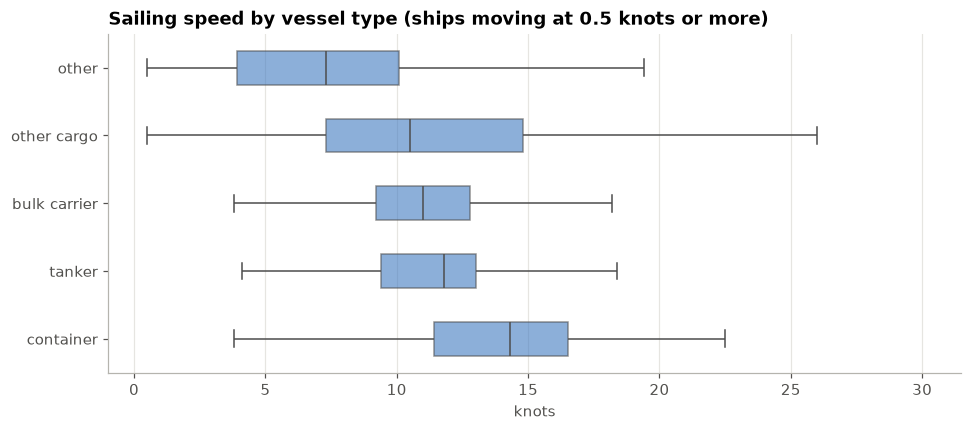

In [34]:
# Only moving ships: compare typical sailing speed by vessel group with a box plot.
moving = speeds[speeds["sog"] >= 0.5]
order = moving.groupby("vessel_group")["sog"].median().sort_values().index

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=moving, x="sog", y="vessel_group", order=order, color=BLUE, fliersize=0,
            width=0.5, boxprops={"alpha": 0.6}, ax=ax)
ax.set_title("Sailing speed by vessel type (ships moving at 0.5 knots or more)")
ax.set_xlabel("knots")
ax.set_ylabel("")
plt.show()

The box covers the middle 50% of speeds, and the line inside it is the median. Container ships
usually sail fastest, since their cargo is time-sensitive, while tankers and bulk carriers go slower to save fuel.

### 6c. Where were the ships on the latest day?

Plotting three groups only keeps the colors easy to tell apart. Everything else is drawn in light gray as background.

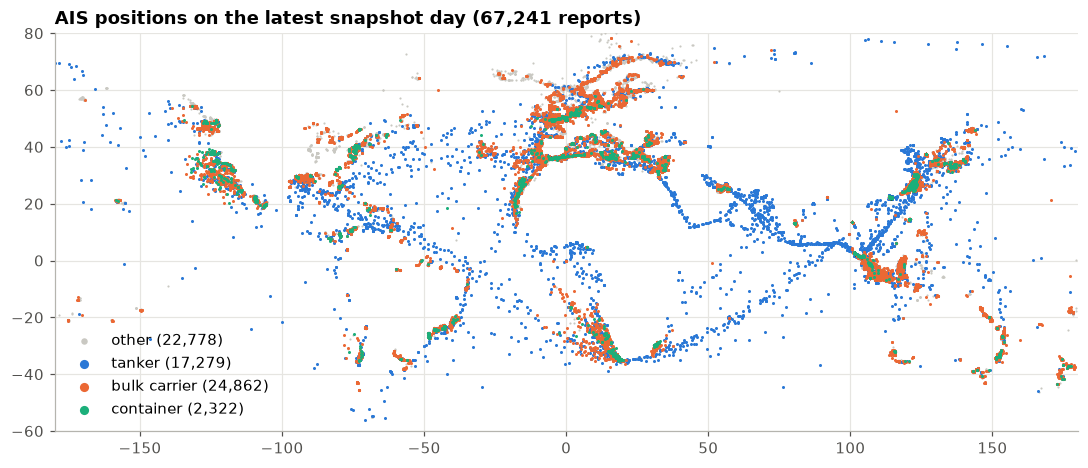

In [35]:
latest = sql(f'''
    SELECT {VESSEL_GROUP} AS vessel_group, latitude, longitude
    FROM ais_positions
    WHERE partition_date = (SELECT max(partition_date) FROM ais_positions)
''')

fig, ax = plt.subplots(figsize=(12, 6))
others = latest[~latest["vessel_group"].isin(["tanker", "bulk carrier", "container"])]
ax.scatter(others["longitude"], others["latitude"], s=2, color="#c9c8c2", label=f"other ({len(others):,})", linewidths=0)
for group, color in zip(["tanker", "bulk carrier", "container"], PALETTE):
    g = latest[latest["vessel_group"] == group]
    ax.scatter(g["longitude"], g["latitude"], s=4, color=color, label=f"{group} ({len(g):,})", linewidths=0)
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 80)
ax.set_aspect("equal")
ax.set_title(f"AIS positions on the latest snapshot day ({len(latest):,} reports)")
ax.legend(loc="lower left", markerscale=3)
plt.show()

Gaps in coverage (empty oceans) usually mean there's no receiver nearby, not that there are no ships.

## 7. US trade (Census)

`us_trade_partners` has monthly US imports (`flow_code = 'M'`) and exports (`'X'`) by trading partner and
HS2 product chapter, since 2013. Values are in US dollars.

### 7a. Monthly totals

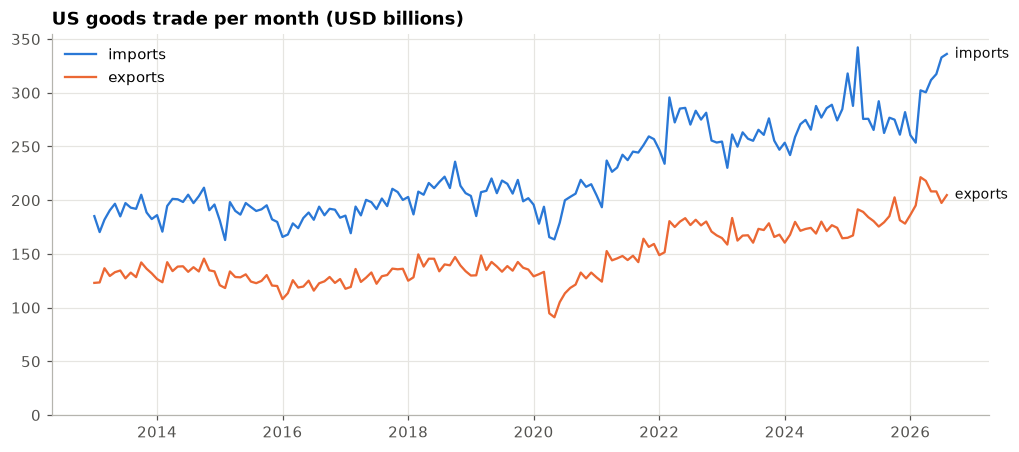

In [36]:
trade = sql('''
    SELECT period_date, flow_code, sum(value_usd) / 1e9 AS value_bn
    FROM us_trade_partners
    GROUP BY ALL
''')
trade["period_date"] = pd.to_datetime(trade["period_date"])
trade = trade.pivot(index="period_date", columns="flow_code", values="value_bn").rename(
    columns={"M": "imports", "X": "exports"}
).sort_index()

fig, ax = plt.subplots()
ax.plot(trade.index, trade["imports"], color=BLUE, label="imports")
ax.plot(trade.index, trade["exports"], color=ORANGE, label="exports")
for col in ["imports", "exports"]:
    ax.text(trade.index[-1], trade[col].iloc[-1], f"  {col}", fontsize=9, color=INK, va="center")
ax.set_title("US goods trade per month (USD billions)")
ax.set_ylim(bottom=0)
ax.legend(loc="upper left")
plt.show()

Imports and exports share a unit (dollars), so they can share an axis. The **trade balance** is
a different quantity, so it gets its own chart rather than a second y-axis on the first.

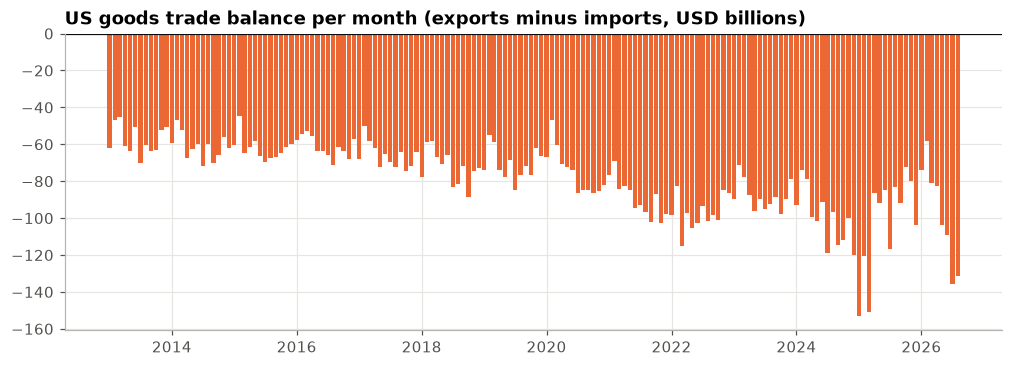

In [37]:
balance = trade["exports"] - trade["imports"]
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar(balance.index, balance, width=25, color=np.where(balance < 0, ORANGE, BLUE))
ax.axhline(0, color=INK, linewidth=0.8)
ax.set_title("US goods trade balance per month (exports minus imports, USD billions)")
plt.show()

### 7b. Top trading partners, last 12 months

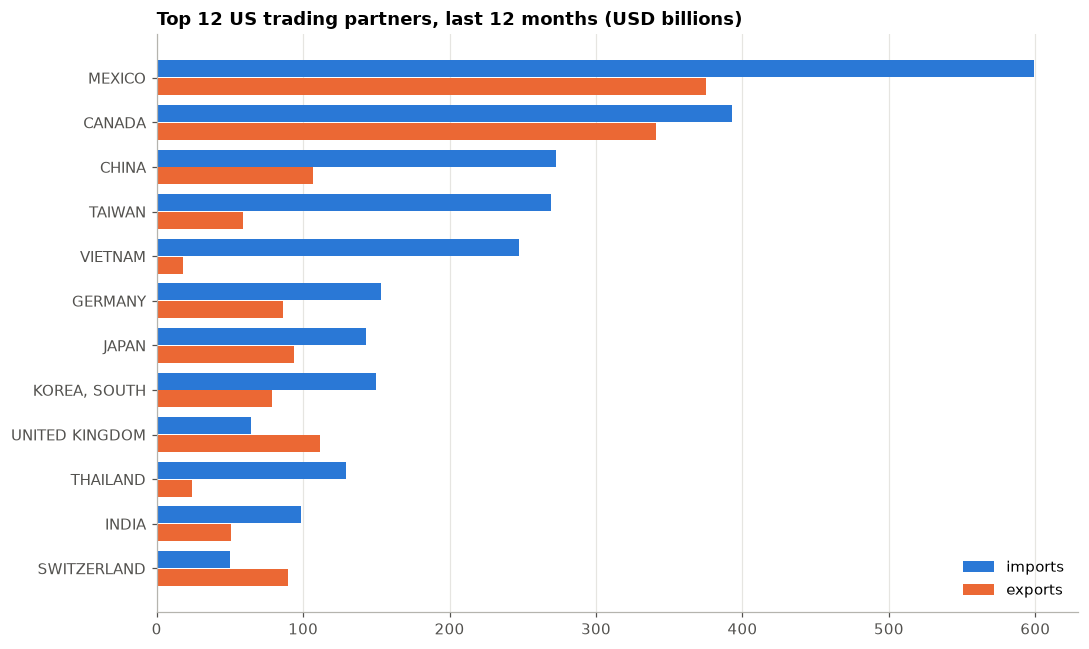

In [38]:
partners = sql('''
    SELECT partner_name, flow_code, sum(value_usd) / 1e9 AS value_bn
    FROM us_trade_partners
    WHERE period_date > (SELECT max(period_date) FROM us_trade_partners) - INTERVAL 12 MONTH
    GROUP BY ALL
''').pivot(index="partner_name", columns="flow_code", values="value_bn").fillna(0)
partners = partners.rename(columns={"M": "imports", "X": "exports"})
partners["total"] = partners["imports"] + partners["exports"]
top = partners.nlargest(12, "total").iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(top))
ax.barh(y + 0.2, top["imports"], height=0.38, color=BLUE, label="imports")
ax.barh(y - 0.2, top["exports"], height=0.38, color=ORANGE, label="exports")
ax.set_yticks(y, top.index)
ax.set_title("Top 12 US trading partners, last 12 months (USD billions)")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 7c. What the US imports most (by HS2 chapter)

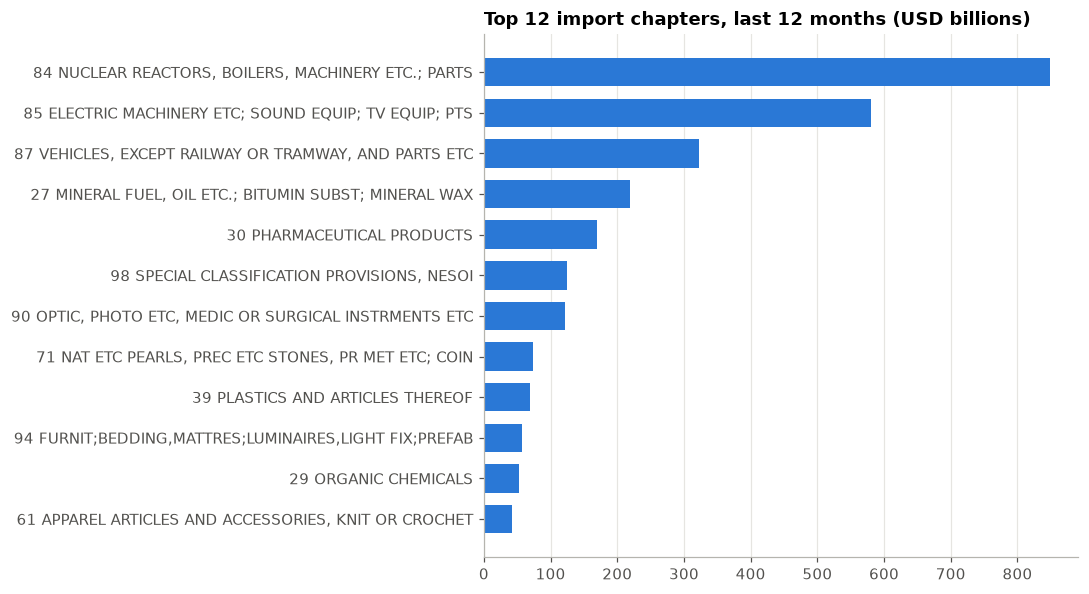

In [39]:
products = sql('''
    SELECT commodity_code || ' ' || any_value(commodity_desc) AS chapter,
           sum(value_usd) / 1e9 AS imports_bn
    FROM us_trade_partners
    WHERE flow_code = 'M'
      AND period_date > (SELECT max(period_date) FROM us_trade_partners) - INTERVAL 12 MONTH
    GROUP BY commodity_code
    ORDER BY imports_bn DESC
    LIMIT 12
''')
products["chapter"] = products["chapter"].str.slice(0, 55)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(products["chapter"][::-1], products["imports_bn"][::-1], color=BLUE, height=0.7)
ax.set_title("Top 12 import chapters, last 12 months (USD billions)")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## 8. US grain export sales (USDA)

`us_export_sales` is USDA's weekly export sales report for corn, soybeans and wheat, per buying country,
back to 1999. `accumulated_exports` is the season-to-date total, in metric tons.

Grain runs on a **marketing year**, not the calendar year (soybeans and corn: September–August;
wheat: June–May). To compare seasons, we number the weeks within each marketing year and overlay them.
This is a **window function**: `row_number() OVER (PARTITION BY ... ORDER BY ...)` numbers rows within each group.

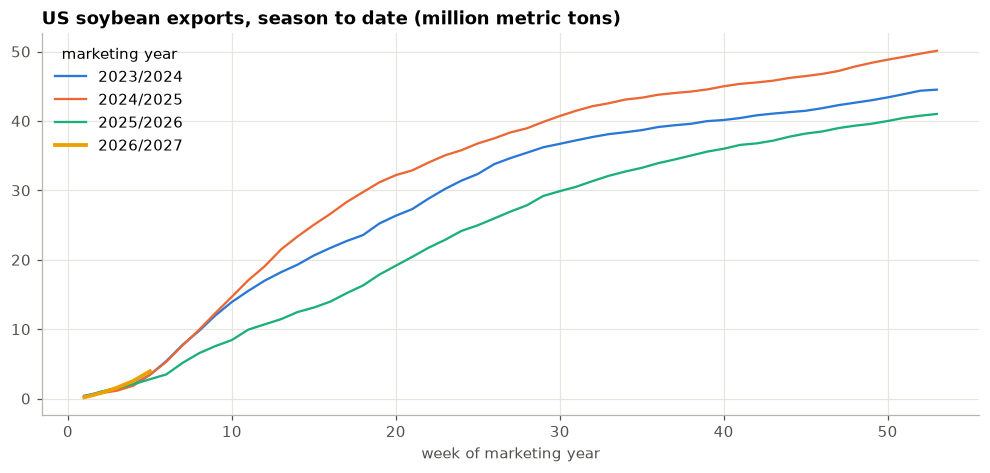

In [40]:
soy = sql('''
    WITH by_week AS (
        SELECT marketing_year, week_ending, sum(accumulated_exports) / 1e6 AS accumulated_mmt
        FROM us_export_sales
        WHERE commodity = 'Soybeans'
        GROUP BY ALL
    )
    SELECT *, row_number() OVER (PARTITION BY marketing_year ORDER BY week_ending) AS week_of_year
    FROM by_week
''')
seasons = sorted(soy["marketing_year"].unique())[-4:]  # the 4 most recent marketing years

fig, ax = plt.subplots()
for season, color in zip(seasons, [PALETTE[0], PALETTE[1], PALETTE[2], PALETTE[3]]):
    s = soy[soy["marketing_year"] == season].sort_values("week_of_year")
    ax.plot(s["week_of_year"], s["accumulated_mmt"], color=color,
            linewidth=2.5 if season == seasons[-1] else 1.5, label=season)
ax.set_title("US soybean exports, season to date (million metric tons)")
ax.set_xlabel("week of marketing year")
ax.legend(title="marketing year", loc="upper left")
plt.show()

The current season is the thick line. If it sits below last season at the same week, exports are running slower.

### Who buys US soybeans?

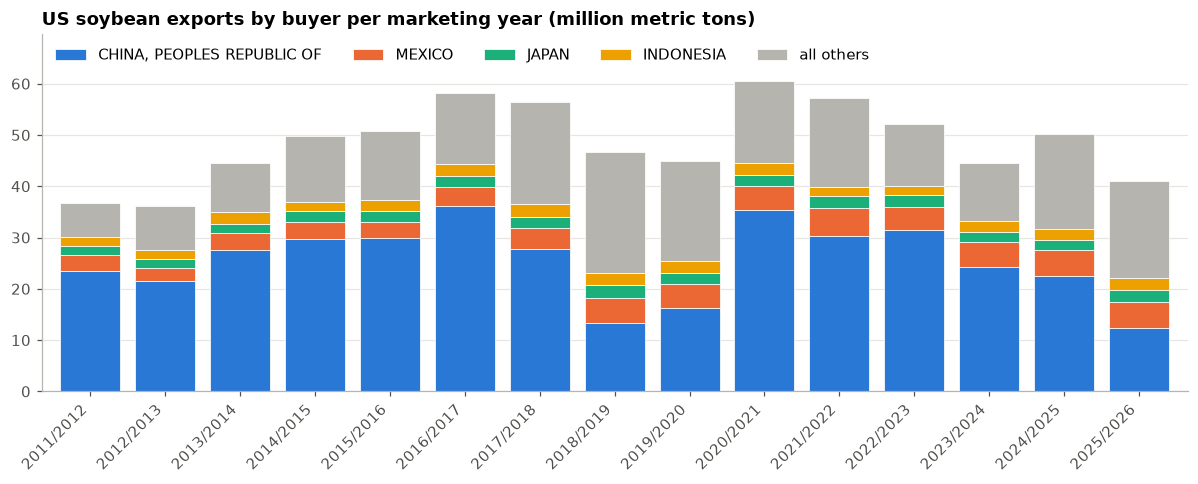

In [41]:
buyers = sql('''
    SELECT marketing_year, country, max(accumulated_exports) / 1e6 AS season_total_mmt
    FROM us_export_sales
    WHERE commodity = 'Soybeans'
    GROUP BY ALL
''')
by_year = buyers.pivot_table(index="marketing_year", columns="country", values="season_total_mmt", aggfunc="sum").fillna(0)
by_year = by_year.iloc[:-1]  # drop the current, unfinished season
top_buyers = by_year.sum().nlargest(4).index
plot_df = by_year[top_buyers].copy()
plot_df["all others"] = by_year.drop(columns=top_buyers).sum(axis=1)
plot_df = plot_df.iloc[-15:]

fig, ax = plt.subplots()
plot_df.plot(kind="bar", stacked=True, ax=ax, width=0.8, edgecolor="white", linewidth=0.5,
             color=PALETTE[: len(top_buyers)] + ["#b5b4ae"])
ax.set_title("US soybean exports by buyer per marketing year (million metric tons)")
ax.set_xlabel("")
ax.legend(loc="upper left", ncols=5)
ax.set_ylim(0, plot_df.sum(axis=1).max() * 1.15)
ax.grid(axis="x", visible=False)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Part of the gray "all others" in recent seasons is USDA's `UNKNOWN` destination: sales where the buyer hasn't
been named yet. China's share depends a lot on how you treat it.

## 9. Oil prices

`oil_prices` has daily Brent and WTI crude prices back to 1986 (from FRED).

In [42]:
oil = sql('''
    SELECT price_date, brent_usd, wti_usd
    FROM oil_prices
    WHERE brent_usd IS NOT NULL OR wti_usd IS NOT NULL
    ORDER BY price_date
''')
oil["price_date"] = pd.to_datetime(oil["price_date"])
oil = oil.set_index("price_date")

oil.describe().T[["count", "mean", "min", "max"]]

,count,mean,min,max
brent_usd,"9,102.00",54.43,9.10,143.95
wti_usd,"9,517.00",50.00,-36.98,145.31


### 9a. Check coverage before plotting

The `count` row above is a warning sign: about 9,100 Brent prices but only about 1,100 WTI prices over the same
40 years. Counting non-null values **per year** shows where the gaps are.

In [43]:
coverage = oil.groupby(oil.index.year)[["brent_usd", "wti_usd"]].count()
coverage.index.name = "year"
coverage.T  # .T (transpose) turns the 41 years into columns so it fits on screen

year,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
brent_usd,0,159,252,250,254,250,245,215,138,127,183,186,189,173,202,194,194,216,230,224,...,247,253,252,252,248,249,252,253,255,255,256,252,257,255,253,252,251,254,253,193
wti_usd,227,238,253,244,255,252,249,239,211,223,198,203,228,165,220,228,229,139,185,204,...,248,253,250,252,212,252,250,248,244,252,250,249,250,252,251,251,248,250,248,191


There are about 250 trading days a year. When this notebook was written (2026-10-03), WTI was complete only for 1986
and nearly empty after 2007, and Brent had gaps too (1994–2002). Adding the two counts for any year gave roughly 250:
**most dates had one of the two prices, but not both.**

The cause was in the collector (`src/collectors/fred_oil.py`). It asked FRED for "the last 30 days" of both series,
but FRED applied that window only to the first series (WTI) and sent Brent's full history. Each write replaces whole
rows, so every daily run overwrote about 9,000 old dates with a Brent price and an empty WTI. The fix sends the date
window for each series, and CI now re-downloads the full history every run, which repairs the table.

**If the counts above now show about 250 for both series in most years, the repair has been published.**
Either way, this check is how the bug was found: always count non-null values per period before trusting a series.
The rest of this section uses Brent only, so it works either way.

In [44]:
# How many dates have both prices?
both = oil["brent_usd"].notna() & oil["wti_usd"].notna()
print(f"{len(oil):,} dates | both prices: {both.sum():,} | Brent only: {(oil['wti_usd'].isna()).sum():,} | WTI only: {(oil['brent_usd'].isna()).sum():,}")

10,209 dates | both prices: 8,410 | Brent only: 692 | WTI only: 1,107


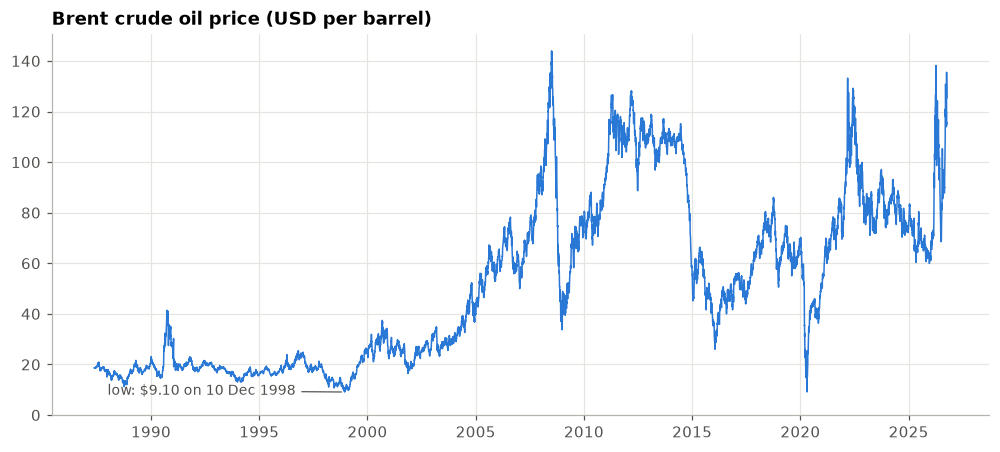

Lowest close in 2020: $9.12 on 21 Apr 2020


In [45]:
brent = oil["brent_usd"].dropna()
fig, ax = plt.subplots()
ax.plot(brent.index, brent, color=BLUE, linewidth=1)
low_date = brent.idxmin()
ax.annotate(f"low: ${brent.min():.2f} on {low_date:%d %b %Y}", xy=(low_date, brent.min()),
            xytext=(low_date - pd.Timedelta(days=4000), 8), fontsize=9, color=MUTED,
            arrowprops={"arrowstyle": "-", "color": MUTED, "linewidth": 0.8})
ax.set_title("Brent crude oil price (USD per barrel)")
ax.set_ylim(bottom=0)
plt.show()

print(f"Lowest close in 2020: ${brent['2020'].min():.2f} on {brent['2020'].idxmin():%d %b %Y}")

The two lowest points are late 1998 (an oil glut after the Asian financial crisis) and April 2020
(COVID lockdowns). Both look like outliers, and both are real. Check what was happening on an outlier's date before
deleting it.

### 9b. Does Hormuz tanker traffic line up with oil prices?

About a fifth of the world's oil passes through the Strait of Hormuz. A natural question is whether
weeks with unusual tanker traffic there are also weeks when Brent moves. We **join** the two tables on week,
then scatter weekly % changes against each other.

We stop at the end of February 2026. After that, Hormuz traffic drops to near zero (the 2026 closure, section 5d), and % changes
from a base of 2–5 tankers a day swing by hundreds of percent, which would swamp the chart.

Pearson r = 0.06 | Spearman = 0.10


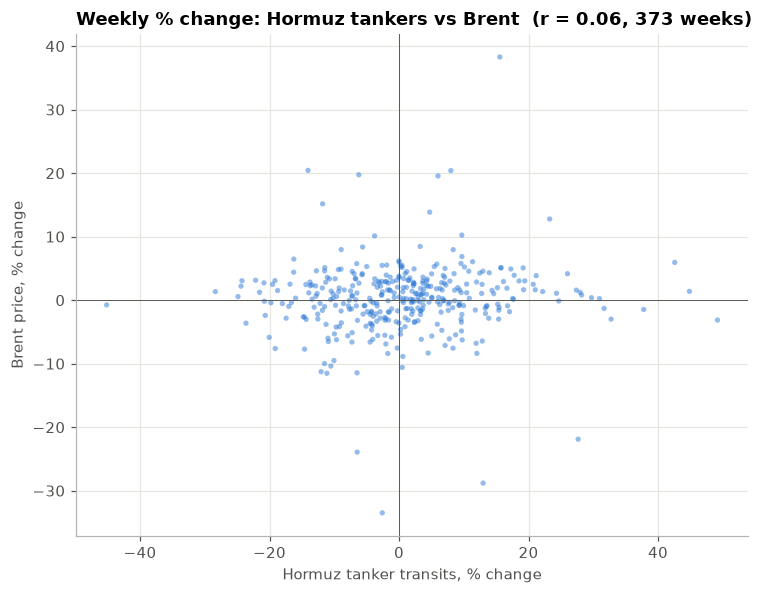

In [46]:
joined = sql('''
    WITH hormuz AS (
        SELECT date_trunc('week', transit_date) AS week, avg(n_tanker) AS tankers_per_day
        FROM chokepoint_daily
        WHERE chokepoint_name = 'Strait of Hormuz'
        GROUP BY ALL
    ),
    brent AS (
        SELECT date_trunc('week', price_date) AS week, avg(brent_usd) AS brent
        FROM oil_prices
        WHERE brent_usd IS NOT NULL
        GROUP BY ALL
    )
    SELECT week, tankers_per_day, brent
    FROM hormuz JOIN brent USING (week)
    WHERE week < DATE '2026-03-01'
    ORDER BY week
''').set_index("week")

chg = joined.pct_change().dropna() * 100
r = chg["tankers_per_day"].corr(chg["brent"])
r_rank = chg["tankers_per_day"].corr(chg["brent"], method="spearman")
print(f"Pearson r = {r:.2f} | Spearman = {r_rank:.2f}")

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(chg["tankers_per_day"], chg["brent"], s=12, color=BLUE, alpha=0.5, edgecolor="none")
ax.axhline(0, color=MUTED, linewidth=0.6)
ax.axvline(0, color=MUTED, linewidth=0.6)
ax.set_title(f"Weekly % change: Hormuz tankers vs Brent  (r = {r:.2f}, {len(chg)} weeks)")
ax.set_xlabel("Hormuz tanker transits, % change")
ax.set_ylabel("Brent price, % change")
plt.tight_layout()
plt.show()

Both correlations are weak (around 0.1 or less), so **in the same week**, tanker traffic tells you little about the price move.
That matches the pipeline's oil-price project (`src/ml/oil_price/`), which found traffic didn't beat a
"no change" forecast. A correlation like this is a quick first check, not proof: it only measures *straight-line*,
*same-week* relationships.

## 10. From export sales to a forecast (grain, continued)

Section 8 used the raw weekly sales. The pipeline publishes three more grain tables built on top of them:

| Table | What it is |
|---|---|
| `usda_wasde` | USDA's monthly supply and demand report (WASDE): every line of every report since 2010, **as first published** |
| `grain_export_pace` | Season-to-date sales per crop per week, compared with last season and the 5-year average |
| `grain_export_forecast` | The pipeline's own forecast of each crop's full-season exports, with a likely range |

### 10a. An estimate is not a fact: USDA's revisions

USDA's first estimate of a season's exports comes out about 16 months before the season ends. It is then
revised every month. `usda_wasde` keeps every version, one per `release_date`. Plotting one season's
estimate against the date it was published shows how far the first guess can be from the final number.

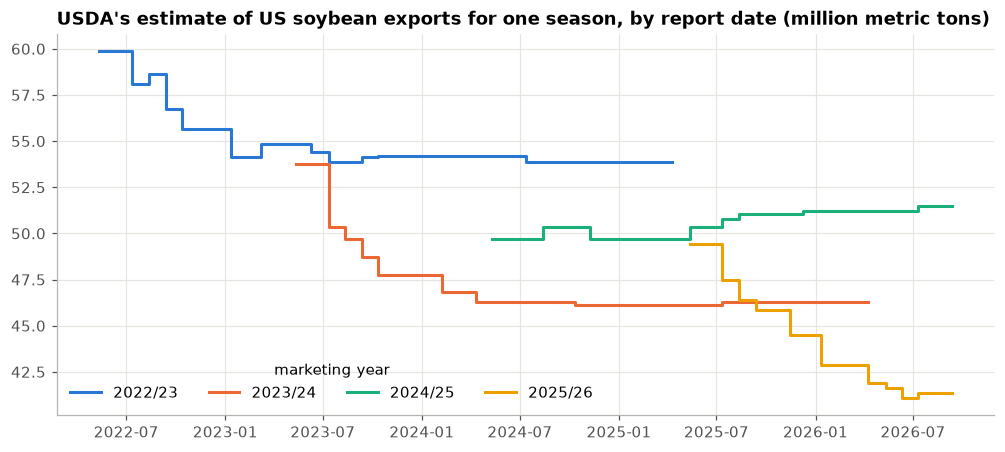

,first_estimate,latest_estimate,n_reports,change_pct
market_year,,,,
2022/23,59.87,53.87,36,-10.02
2023/24,53.75,46.27,35,-13.92
2024/25,49.67,51.50,28,3.68
2025/26,49.40,41.37,16,-16.26


In [47]:
wasde = sql('''
    SELECT market_year, release_date, value AS exports_mmt
    FROM usda_wasde
    WHERE report_title = 'World Soybean Supply and Use'
      AND commodity = 'Oilseed, Soybean'
      AND region = 'United States'
      AND attribute = 'Exports'
      AND period = 'Annual'
      AND unit = 'Million Metric Tons'
      AND market_year IN ('2022/23', '2023/24', '2024/25', '2025/26')
    ORDER BY release_date
''')
wasde["release_date"] = pd.to_datetime(wasde["release_date"])

fig, ax = plt.subplots()
for season, color in zip(sorted(wasde["market_year"].unique()), PALETTE):
    s = wasde[wasde["market_year"] == season]
    # A step line: each estimate stays in force until the next report replaces it.
    ax.step(s["release_date"], s["exports_mmt"], where="post", color=color, linewidth=2, label=season)
ax.set_title("USDA's estimate of US soybean exports for one season, by report date (million metric tons)")
ax.legend(title="marketing year", loc="lower left", ncols=4)
plt.show()

revisions = wasde.groupby("market_year").agg(
    first_estimate=("exports_mmt", "first"), latest_estimate=("exports_mmt", "last"), n_reports=("exports_mmt", "size")
)
revisions["change_pct"] = (revisions["latest_estimate"] / revisions["first_estimate"] - 1) * 100
revisions

In three of these four seasons, USDA's latest number is 10–16% below its first. For 2025/26 the cut is the biggest,
from 49.4 to 41.4 million tons. China, the largest buyer, took 12.4 million tons of US soybeans that season, against
22.5 the season before (you can check this with section 8's query).

This matters whenever you test a forecast on past seasons. Compare it with what USDA said **at the time**, not the
final revised number. Otherwise the comparison gives USDA information it didn't have yet.

### 10b. Ahead or behind? The pace table

`grain_export_pace` has one row per crop per week of the marketing year. `commitments_mt` is everything sold so
far this season (shipped plus booked but not yet shipped). The `_vs_` columns compare it with the same week last season
and with the average of the last 5 seasons.

In [48]:
pace = sql('''
    SELECT commodity, marketing_year, my_week, week_ending,
           commitments_mt / 1e6 AS committed_mmt,
           commitments_vs_prior_year_pct,
           commitments_vs_avg5_pct
    FROM grain_export_pace
    -- keep each crop's latest week
    QUALIFY row_number() OVER (PARTITION BY commodity ORDER BY week_ending DESC) = 1
    ORDER BY commodity
''')
pace

,commodity,marketing_year,my_week,week_ending,committed_mmt,commitments_vs_prior_year_pct,commitments_vs_avg5_pct
0,Corn,2026/2027,5,2026-10-01,19.54,-33.60,-4.40
1,Soybeans,2026/2027,5,2026-10-01,22.79,79.90,8.80
2,Wheat,2026/2027,18,2026-10-01,10.11,-31.90,-13.60


`QUALIFY` is a filter applied *after* a window function, so "the latest row per group" needs no subquery.


Soybean sales are 89% ahead of last season, but only 11% above the 5-year average: last season started unusually
slowly. "Versus last year" alone would exaggerate the gain, which is why the table carries two baselines.

### 10c. The pipeline's forecast for this season

`grain_export_forecast` holds one forecast per crop per week of the current season. It starts from USDA's estimate
(`usda_mt`), adjusts it using how fast sales are going (`pace_projection_mt`), and gives a likely range
(`forecast_low_mt` to `forecast_high_mt`) taken from how wrong the same method was in past seasons.
The method and its backtest are in `src/ml/grain_forecast/`. Wheat has the most weeks so far, because its season
starts in June.

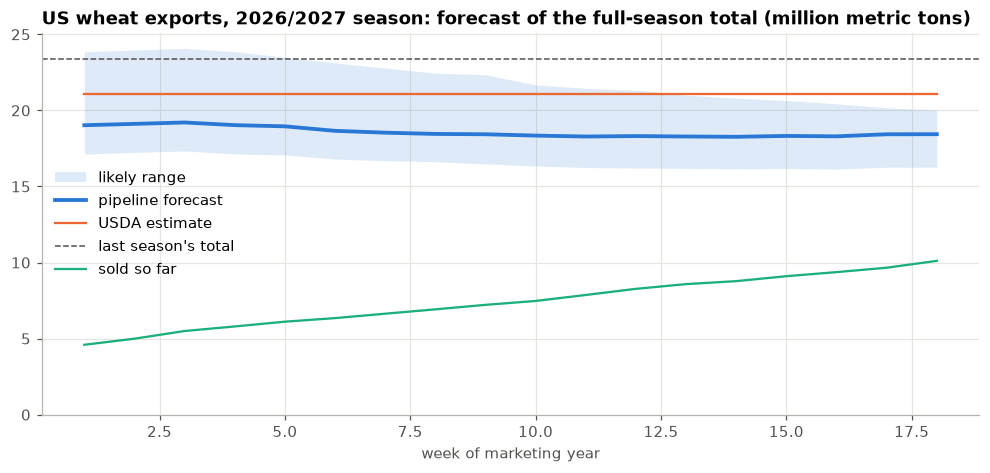

In [49]:
fc = sql('''
    SELECT marketing_year, my_week, week_ending,
           commitments_mt / 1e6 AS committed,
           forecast_mt / 1e6 AS forecast,
           forecast_low_mt / 1e6 AS low,
           forecast_high_mt / 1e6 AS high,
           usda_mt / 1e6 AS usda,
           last_season_mt / 1e6 AS last_season
    FROM grain_export_forecast
    WHERE commodity = 'Wheat'
    ORDER BY my_week
''')

fig, ax = plt.subplots()
ax.fill_between(fc["my_week"], fc["low"], fc["high"], color=BLUE, alpha=0.15, linewidth=0, label="likely range")
ax.plot(fc["my_week"], fc["forecast"], color=BLUE, linewidth=2.5, label="pipeline forecast")
ax.step(fc["my_week"], fc["usda"], where="post", color=ORANGE, label="USDA estimate")
ax.axhline(fc["last_season"].iloc[0], color=MUTED, linestyle="--", linewidth=1, label="last season's total")
ax.plot(fc["my_week"], fc["committed"], color=AQUA, label="sold so far")
ax.set_ylim(bottom=0)
ax.set_title(f"US wheat exports, {fc['marketing_year'].iloc[0]} season: forecast of the full-season total (million metric tons)")
ax.set_xlabel("week of marketing year")
ax.legend(loc="center left")
plt.show()

The forecast (about 18.4 million tons) is below USDA's 21.1 and well below last season's 23.4, because sales are running
31% behind last season. The range starts wide and narrows as the season goes on, since more of the total is already sold.

Two cautions from the backtest (`src/ml/grain_forecast/README.md`):
- For wheat, the forecast only starts beating "same as last season" from about week 16.
- The likely range held the final total in about 7 of 10 past seasons. So roughly 3 seasons in 10 end up outside it.

## 11. Checking a proxy against the official numbers: IMF trade nowcasts

`trade_nowcast` is IMF PortWatch's monthly estimate of each country's trade, built from ship traffic: how many
cargo ships called at the country's ports, and how full they were. Its value columns are **index numbers**, not dollars.
The official US numbers (Census, section 7) come out about two months later, so a nowcast is only worth using
if it tracks them.

Two checks:
1. **Levels.** Rebase both series to *2019 average = 100*, so they share a scale, and plot them together.
2. **Year-over-year changes.** Two series that both trend upward will correlate in levels even if they're unrelated.
   Comparing each month with the same month a year earlier is the harder test. It also removes seasonality.

Correlation, levels: 0.81 | year-over-year changes: 0.77
Latest nowcast month: 2026-08 | latest Census month: 2026-08


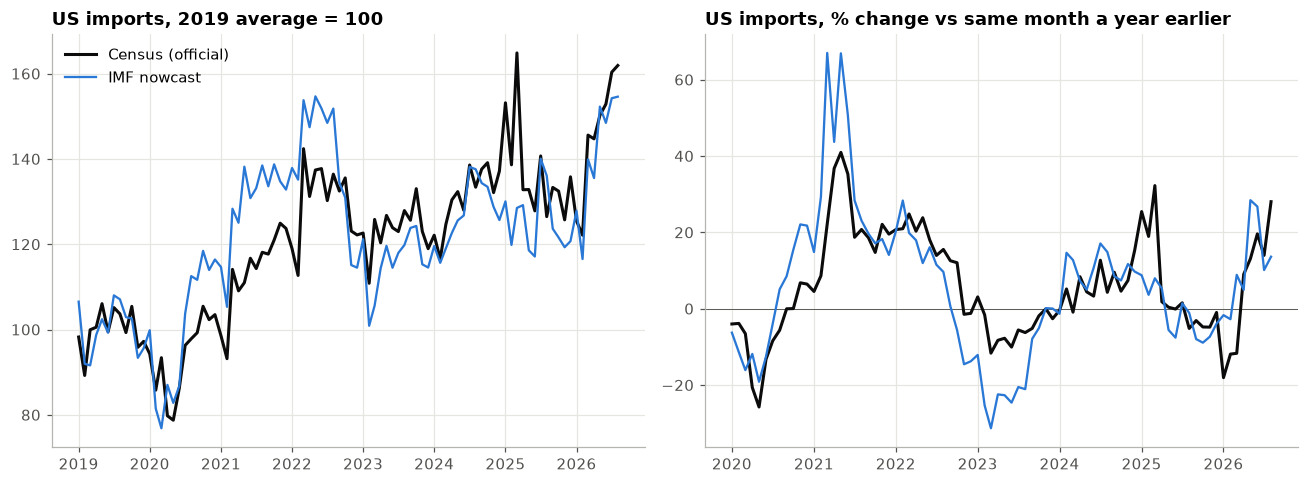

In [50]:
check = sql('''
    WITH census AS (
        SELECT period_date AS month, sum(value_usd) / 1e9 AS census_imports_bn
        FROM us_trade_partners
        WHERE flow_code = 'M'
        GROUP BY ALL
    )
    SELECT n.month_date AS month, n.value_import_total AS nowcast_index, c.census_imports_bn
    FROM trade_nowcast n
    LEFT JOIN census c ON c.month = n.month_date
    WHERE n.iso3 = 'USA'
    ORDER BY month
''')
check["month"] = pd.to_datetime(check["month"])
check = check.set_index("month")

base = check[check.index.year == 2019].mean()
rebased = check / base * 100
yoy = check.pct_change(12, fill_method=None) * 100

r_level = rebased.corr().iloc[0, 1]
r_yoy = yoy.corr().iloc[0, 1]
print(f"Correlation, levels: {r_level:.2f} | year-over-year changes: {r_yoy:.2f}")
print(f"Latest nowcast month: {check.index.max():%Y-%m} | latest Census month: {check['census_imports_bn'].last_valid_index():%Y-%m}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(rebased.index, rebased["census_imports_bn"], color=INK, linewidth=2, label="Census (official)")
axes[0].plot(rebased.index, rebased["nowcast_index"], color=BLUE, label="IMF nowcast")
axes[0].set_title("US imports, 2019 average = 100")
axes[0].legend(loc="upper left")
axes[1].axhline(0, color=MUTED, linewidth=0.6)
axes[1].plot(yoy.index, yoy["census_imports_bn"], color=INK, linewidth=2, label="Census (official)")
axes[1].plot(yoy.index, yoy["nowcast_index"], color=BLUE, label="IMF nowcast")
axes[1].set_title("US imports, % change vs same month a year earlier")
plt.tight_layout()
plt.show()

The nowcast tracks the official numbers well, in levels and in year-over-year changes. It is also a month ahead:
August is already in, and Census stops at July.

Where the two disagree is informative. In 2021 the nowcast's year-over-year jump was much bigger (about +67% against +41%), and in early 2023 so was its fall (about −30% against −10%).
Ship counts react to port congestion and container shortages, not only to the value of goods.
So use the nowcast for **direction**, not for the exact size of a change.

## 12. US ports

### 12a. Port of Los Angeles: full boxes in, empty boxes out

`port_volumes` is the Port of Los Angeles' monthly container count, in **TEU** (twenty-foot equivalent units:
one standard 20-foot container; a 40-foot container is 2 TEU). The port reports loaded and empty containers separately.

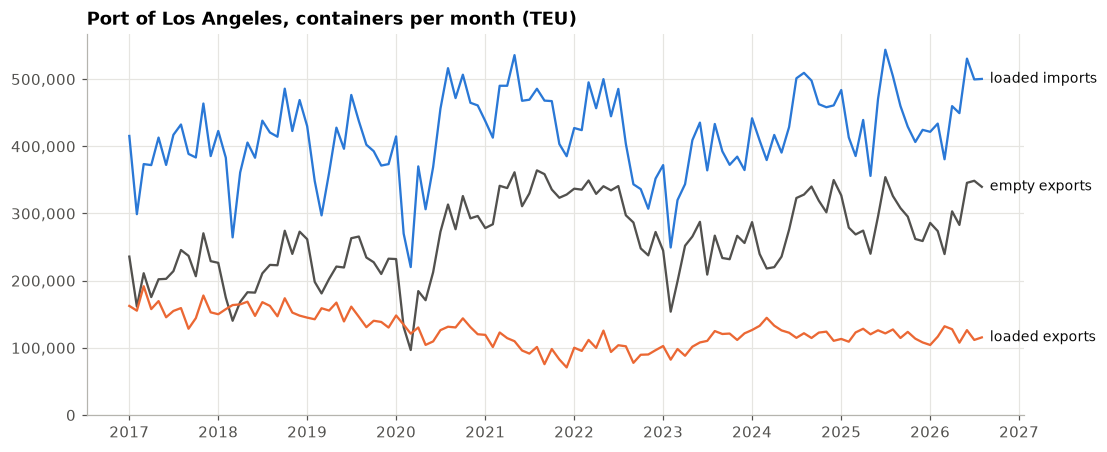

Last 12 months: 72% of outbound containers left empty


In [51]:
la = sql('''
    SELECT period_date, loaded_imports_teu, loaded_exports_teu, empty_exports_teu
    FROM port_volumes
    WHERE port_code = 'USLAX' AND loaded_imports_teu IS NOT NULL
    ORDER BY period_date
''')
la["period_date"] = pd.to_datetime(la["period_date"])
la = la.set_index("period_date")

fig, ax = plt.subplots()
ax.plot(la.index, la["loaded_imports_teu"], color=BLUE, label="loaded imports")
ax.plot(la.index, la["empty_exports_teu"], color=MUTED, label="empty exports")
ax.plot(la.index, la["loaded_exports_teu"], color=ORANGE, label="loaded exports")
for col in la.columns:
    ax.text(la.index[-1], la[col].iloc[-1], "  " + col.removesuffix("_teu").replace("_", " "), fontsize=9, color=INK, va="center")
ax.yaxis.set_major_formatter(thousands)
ax.set_ylim(bottom=0)
ax.set_title("Port of Los Angeles, containers per month (TEU)")
plt.show()

recent = la.iloc[-12:].sum()
print(f"Last 12 months: {recent['empty_exports_teu'] / (recent['empty_exports_teu'] + recent['loaded_exports_teu']):.0%} "
      "of outbound containers left empty")

Loaded imports run about 4 times loaded exports. The US buys far more from Asia than it sells there, so most containers
go back across the Pacific empty: 72% of outbound containers over the last 12 months. Empty exports follow imports
closely, including the 2020–2022 surge.

### 12b. The biggest US ports by tonnage

`port_tonnage_us` is the US Army Corps of Engineers' annual ranking of US ports by cargo weight (short tons).
It splits each port's cargo into **domestic** (between US places, e.g. barges on the Mississippi) and **foreign**
(imports and exports).

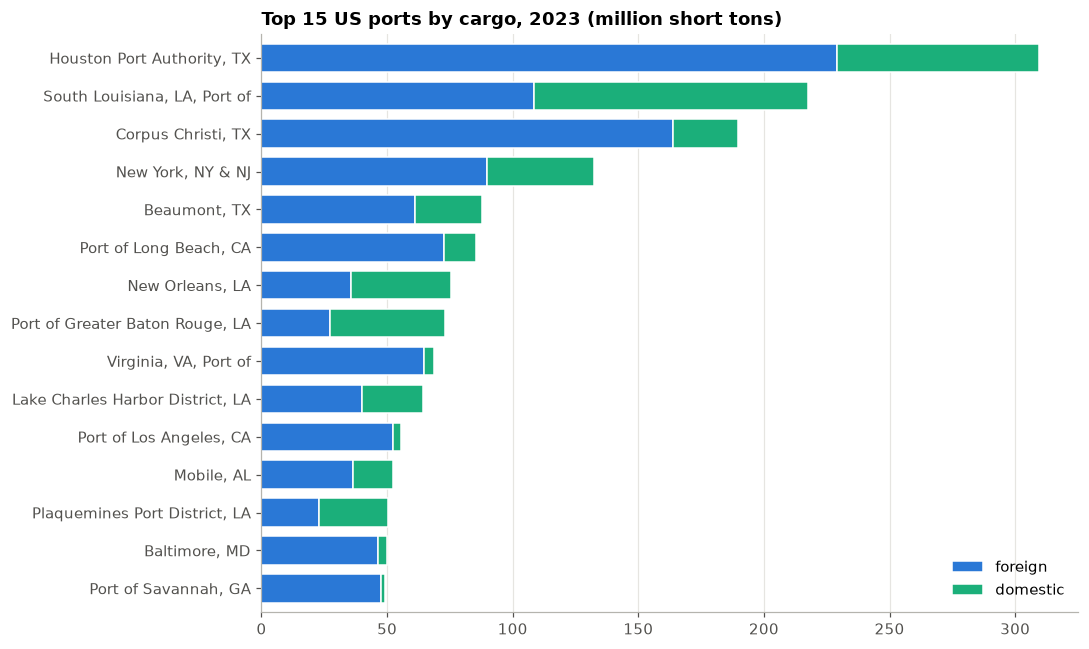

In [52]:
tons = sql('''
    SELECT port_name, port_type, domestic_tons / 1e6 AS domestic, foreign_tons / 1e6 AS "foreign"
    FROM port_tonnage_us
    WHERE data_year = (SELECT max(data_year) FROM port_tonnage_us)
    ORDER BY total_tons DESC
    LIMIT 15
''').set_index("port_name")

fig, ax = plt.subplots(figsize=(10, 6))
tons[["foreign", "domestic"]].iloc[::-1].plot(kind="barh", stacked=True, ax=ax, color=[BLUE, AQUA], width=0.75, edgecolor="white")
ax.set_title(f"Top 15 US ports by cargo, {sql('SELECT max(data_year) FROM port_tonnage_us').iloc[0, 0]} (million short tons)")
ax.set_ylabel("")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

Houston leads by a wide margin, mostly foreign trade in oil and chemicals. The Louisiana ports on the Mississippi
(South Louisiana, New Orleans, Baton Rouge, Plaquemines) are largely **domestic**: barges bringing grain, coal and fuel down the river.
Los Angeles, the country's busiest container port (12a), ranks only 11th by weight, because containers carry valuable but
relatively light goods. Which port is "biggest" depends on what you measure.

### 12c. A billion-byte table in seconds: every ship track in US waters

`vessel_tracks_us` is the biggest table in the dataset: about 38 million rows and 1 GB. Each row is one *track*,
a vessel's continuous movement within one day, from NOAA's AIS archive. It is published 5 to 6 months after the fact.

Querying it straight from Hugging Face still takes only seconds, because parquet is a **columnar** format:
the file stores each column separately, so DuckDB downloads only the columns the query names (here 3 of 19).
`SELECT *` on this table would download all of it.

Query took 22.7 s


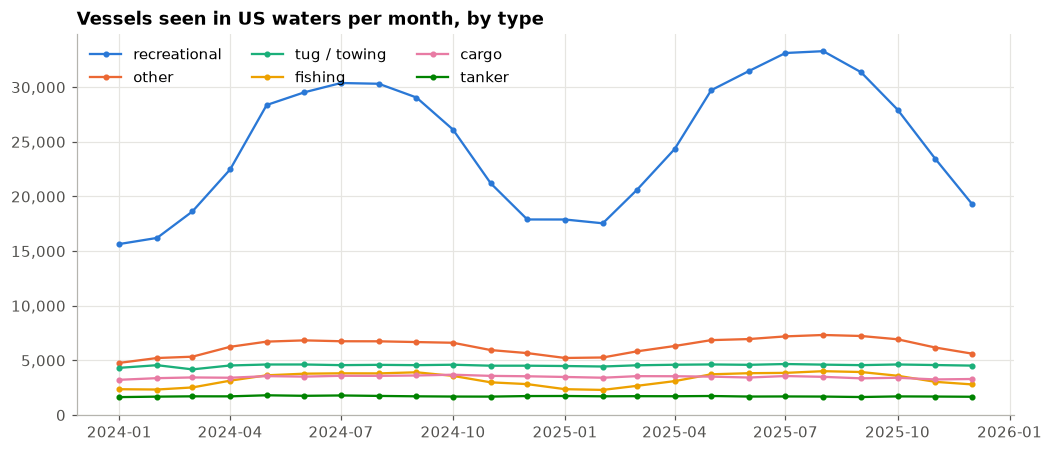

In [53]:
import time

start = time.perf_counter()
tracks = sql('''
    SELECT track_month,
           CASE
               WHEN vessel_type_name IN ('Pleasure Craft', 'Sailing') THEN 'recreational'
               WHEN vessel_type_name LIKE 'Cargo%'  THEN 'cargo'
               WHEN vessel_type_name LIKE 'Tanker%' THEN 'tanker'
               WHEN vessel_type_name = 'Fishing'    THEN 'fishing'
               WHEN vessel_type_name IN ('Tug', 'Towing ahead or alongside') THEN 'tug / towing'
               ELSE 'other'
           END AS vessel_group,
           count(DISTINCT mmsi) AS vessels
    FROM vessel_tracks_us
    GROUP BY ALL
    ORDER BY track_month
''')
print(f"Query took {time.perf_counter() - start:.1f} s")

tracks["track_month"] = pd.to_datetime(tracks["track_month"])
wide = tracks.pivot(index="track_month", columns="vessel_group", values="vessels")
order = ["recreational", "other", "tug / towing", "fishing", "cargo", "tanker"]

fig, ax = plt.subplots()
for group, color in zip(order, PALETTE):
    ax.plot(wide.index, wide[group], color=color, marker="o", markersize=3, label=group)
ax.yaxis.set_major_formatter(thousands)
ax.set_ylim(bottom=0)
ax.set_title("Vessels seen in US waters per month, by type")
ax.legend(loc="upper left", ncols=3)
plt.show()

Recreational boats roughly double from winter to summer. Cargo ships (about 3,500 a month) and tankers (about 1,700) barely
change, because the commercial fleet works all year. The data ends in December 2025, since NOAA publishes about 5 months late.

## 13. Supply chain pressure and port congestion

### 13a. The New York Fed's Global Supply Chain Pressure Index

`supply_chain_index` is the NY Fed's monthly **GSCPI**. It combines shipping costs, air freight costs and
delivery-time surveys into one number, measured in **standard deviations from its long-run average**:
0 is a normal month, +1 is unusually tight, and anything above +2 is rare.

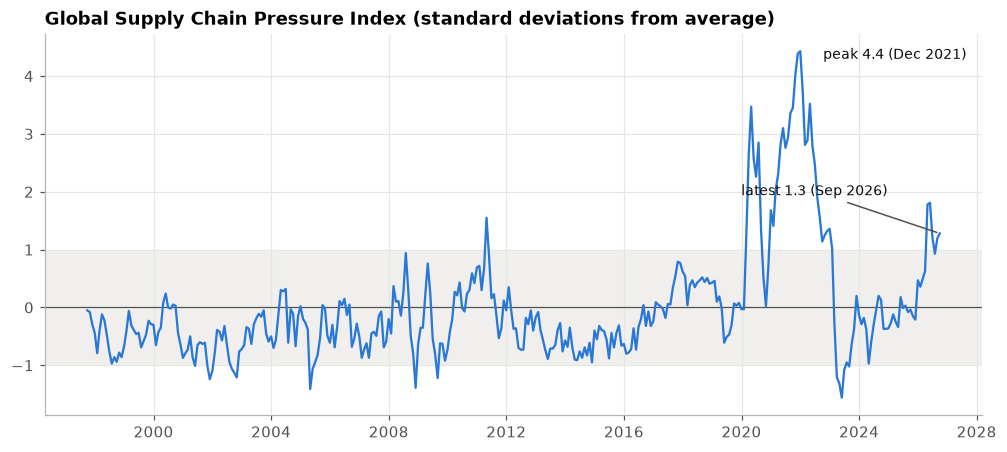

In [54]:
gscpi = sql("SELECT index_date, gscpi_index FROM supply_chain_index ORDER BY index_date")
gscpi["index_date"] = pd.to_datetime(gscpi["index_date"])
gscpi = gscpi.set_index("index_date")["gscpi_index"]

fig, ax = plt.subplots()
ax.axhspan(-1, 1, color="#e6e5e1", alpha=0.6, linewidth=0)  # within 1 standard deviation: normal
ax.axhline(0, color=MUTED, linewidth=0.8)
ax.plot(gscpi.index, gscpi, color=BLUE)
peak = gscpi.idxmax()
ax.annotate(f"peak {gscpi[peak]:.1f} ({peak:%b %Y})", xy=(peak, gscpi[peak]), xytext=(15, -5),
            textcoords="offset points", fontsize=9, color=INK)
ax.annotate(f"latest {gscpi.iloc[-1]:.1f} ({gscpi.index[-1]:%b %Y})", xy=(gscpi.index[-1], gscpi.iloc[-1]),
            xytext=(-130, 25), textcoords="offset points", fontsize=9, color=INK, arrowprops={"arrowstyle": "-", "color": MUTED})
ax.set_title("Global Supply Chain Pressure Index (standard deviations from average)")
plt.show()

The pandemic peak (4.4 in December 2021) is far beyond anything before it. In 2026 the index rose to about 1.8 in
April and May, after the Hormuz closure (section 5d), then eased to about 1 by August. The index is monthly and comes out
with a lag, so it confirms stress after the fact rather than warning of it.

### 13b. Port congestion, and the small-denominator trap

`port_congestion_proxy` compares each port's average daily port calls over the last 7 days with its average over the
previous 90. A ratio of 1.3 means 30% busier than usual. (It measures *traffic*, not ships waiting at anchor, so
"busier than usual" is a hint of congestion, not proof.)

Ratios have a trap: at a port that sees one ship a week, one extra ship doubles the ratio.
Look at how the extreme ratios depend on port size:

In [55]:
cong = sql("SELECT * FROM port_congestion_proxy")
cong["size"] = pd.cut(cong["baseline_avg_portcalls_per_day"], [-0.01, 1, 5, float("inf")],
                      labels=["under 1 call/day", "1-5 calls/day", "5+ calls/day"])
display(cong.groupby("size", observed=True)["ratio_vs_baseline"].describe()[["count", "min", "50%", "max"]])

big = cong[cong["baseline_avg_portcalls_per_day"] >= 5]
cols = ["port_name", "country", "baseline_avg_portcalls_per_day", "recent_avg_portcalls_per_day", "ratio_vs_baseline"]
print(f"As of {cong['as_of'].max():%Y-%m-%d}, ports with 5+ calls a day. Busiest vs usual:")
display(big.nlargest(5, "ratio_vs_baseline")[cols])
print("Quietest vs usual:")
display(big.nsmallest(5, "ratio_vs_baseline")[cols])

,count,min,50%,max
size,,,,
under 1 call/day,"1,063.00",0.00,0.90,12.86
1-5 calls/day,633.00,0.00,0.99,1.82
5+ calls/day,235.00,0.58,1.00,1.34


As of 2026-10-02, ports with 5+ calls a day. Busiest vs usual:


,port_name,country,baseline_avg_portcalls_per_day,recent_avg_portcalls_per_day,ratio_vs_baseline
345,Saint Petersburg,Russian Federation,10.67,14.29,1.34
226,Bilbao,Spain,5.23,7.00,1.34
1772,Matsuyama,Japan,5.77,7.43,1.29
1592,Kashima-Ibaraki,Japan,13.23,17.00,1.28
1766,Masan,Korea,5.68,7.14,1.26


Quietest vs usual:


,port_name,country,baseline_avg_portcalls_per_day,recent_avg_portcalls_per_day,ratio_vs_baseline
1552,Jaigad Port,India,5.44,3.14,0.58
1544,Istanbul,Türkiye,15.44,10.29,0.67
1620,Kinuura,Japan,5.31,3.71,0.70
1348,Eleusis,Greece,5.54,4.14,0.75
834,Zhuhai,China,6.13,4.71,0.77


At ports with under 1 call a day the ratio runs from 0 to almost 13. At ports with 5 or more calls a day it stays between
about 0.6 and 1.3. Most of the extremes at small ports are noise. Before ranking by a ratio, filter out small bases
(or rank on the difference in calls instead).

One name on the "busier" list ties back to section 5d. Fujairah is the UAE's oil port on the Gulf of Oman, outside the
Strait of Hormuz, so it is one of the routes around the strait. For the quiet ports, check what happened that week
(a storm, a holiday) before calling it a trend.

## 14. Oil trade and sanctioned tankers

### 14a. JODI oil data: one number, three rows

`oil_trade` is the JODI Oil database: monthly crude and product balances (production, exports, imports, stocks)
reported by about 110 countries. Despite the name it has no trading partners (`partner_country` is always blank).

Each figure is stored **three times**, once per `unit`. Summing without filtering on `unit` triple-counts and mixes units:

In [56]:
sql('''
    SELECT period, reporting_country, product, flow, unit, quantity_barrels, quantity_ktonnes
    FROM oil_trade
    WHERE reporting_country = 'SA' AND product = 'Crude oil' AND flow = 'Exports' AND period = '2025-06'
''')

,period,reporting_country,product,flow,unit,quantity_barrels,quantity_ktonnes
0,2025-06,SA,Crude oil,Exports,CONVBBL,"7,323.00",NaN
1,2025-06,SA,Crude oil,Exports,KTONS,NaN,"25,158.54"
2,2025-06,SA,Crude oil,Exports,KBBL,"184,236.00",NaN


- `KBBL` is thousand barrels and `KTONS` is thousand metric tons: the same exports in two units.
- `CONVBBL` is not a quantity. It's the **conversion factor** between them (barrels per thousand tonnes):
  25,158.5 kt × 7.323 = 184,236 thousand barrels.

That gives a second trap. A country can have a `CONVBBL` row and no quantity rows at all, so it *looks* present
in a `count(*)` but reports nothing. Which Gulf producers actually report crude export volumes?

In [57]:
gulf_codes = {"SA": "Saudi Arabia", "IQ": "Iraq", "KW": "Kuwait", "AE": "UAE", "QA": "Qatar",
              "IR": "Iran", "OM": "Oman", "BH": "Bahrain"}
codes = ", ".join(f"'{c}'" for c in gulf_codes)
sql(f'''
    SELECT reporting_country, unit, min(period) AS first_month, max(period) AS last_month, count(*) AS n_months
    FROM oil_trade
    WHERE product = 'Crude oil' AND flow = 'Exports' AND period >= '2024-01'
      AND reporting_country IN ({codes})
    GROUP BY ALL
    ORDER BY reporting_country, unit
''').pivot(index="reporting_country", columns="unit", values="last_month").rename(index=gulf_codes)

unit,CONVBBL,KBBL,KTONS
reporting_country,,,
UAE,2026-07,NaN,NaN
Bahrain,2026-07,2026-06,2026-06
Iraq,2026-07,2024-03,2024-03
Iran,2026-07,NaN,NaN
Kuwait,2026-07,2026-07,2026-07
Oman,2026-07,NaN,NaN
Qatar,2026-07,NaN,NaN
Saudi Arabia,2026-07,2026-07,2026-07


Only Saudi Arabia and Kuwait report crude export volumes through 2026 (Bahrain's are tiny, and Iraq stopped in March 2024).
For those two, here are monthly crude exports through the Hormuz closure (section 5d):

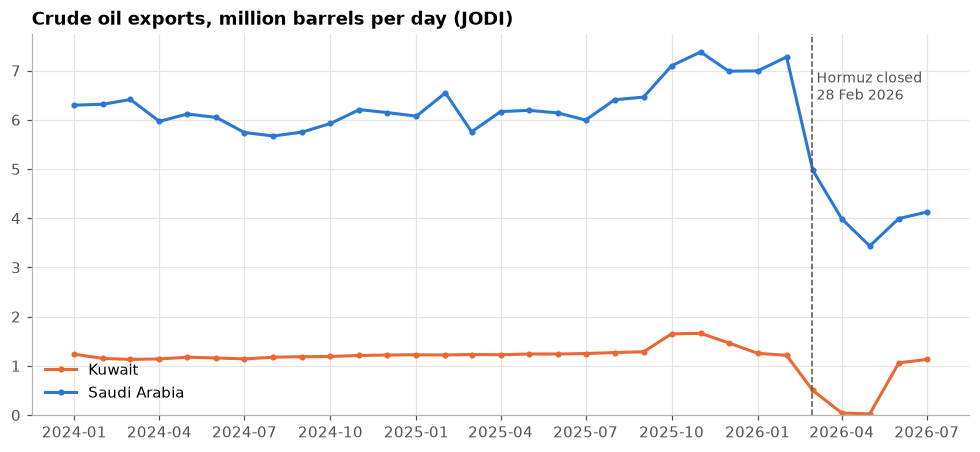

April-May 2026 vs 2025 average: Kuwait -98%, Saudi Arabia -42%


In [58]:
gulf_oil = sql('''
    SELECT strptime(period, '%Y-%m') AS month, reporting_country, quantity_barrels / 1e3 AS mbbl
    FROM oil_trade
    WHERE product = 'Crude oil' AND flow = 'Exports' AND unit = 'KBBL'
      AND reporting_country IN ('SA', 'KW') AND period >= '2024-01'
''').pivot(index="month", columns="reporting_country", values="mbbl").rename(columns=gulf_codes)
# Million barrels per month / days in the month = million barrels per day
per_day = gulf_oil.div(gulf_oil.index.days_in_month, axis=0)

fig, ax = plt.subplots()
for country, color in zip(per_day.columns, [ORANGE, BLUE]):
    ax.plot(per_day.index, per_day[country], color=color, marker="o", markersize=3, linewidth=2, label=country)
ax.axvline(pd.Timestamp("2026-02-28"), color=MUTED, linestyle="--", linewidth=1)
ax.text(pd.Timestamp("2026-03-05"), per_day.max().max() * 0.95, "Hormuz closed\n28 Feb 2026", fontsize=9, color=MUTED, va="top")
ax.set_ylim(bottom=0)
ax.set_title("Crude oil exports, million barrels per day (JODI)")
ax.legend(loc="lower left")
plt.show()

change = per_day.loc["2026-04":"2026-05"].mean() / per_day.loc["2025-01":"2025-12"].mean() - 1
print("April-May 2026 vs 2025 average:", ", ".join(f"{c} {v:+.0%}" for c, v in change.items()))

Kuwait's exports fell 98% in April–May 2026, because all of its oil has to leave through the Gulf. Saudi Arabia's fell
42%, not 100%: it can pipe crude across the country to Red Sea ports such as Yanbu, which section 5d showed getting busier.
Kuwait recovered in June, after the strait reopened.

JODI figures are self-reported, and fewer countries have reported the latest months (111 for late 2025, 84 for July 2026).
Expect recent months to be filled in and revised.

### 14b. Are sanctioned tankers in the AIS data?

`sanctions` is the US Treasury's OFAC sanctions list (the SDN list). It names people, companies, aircraft and vessels.
We use only the **vessels** here.

Vessels are identified by their **IMO number**, a ship's permanent 7-digit ID that stays the same when it is
renamed or re-flagged. OFAC's file has no IMO column; the number is written in the free-text `remarks`, e.g.
*"Vessel Registration Identification IMO 9113379; MMSI ..."*. The pipeline's collector pulls it out into `imo_number`.

`imo_number` is text (`VARCHAR`), while `ais_positions.imo` is a number (`BIGINT`). A join between a text column and a
number column either fails or silently matches nothing, so cast one side first. `TRY_CAST` turns anything that
isn't a number into NULL instead of raising an error.

`programs` packs several sanctions programs into one string, like `UKRAINE-EO13662] [RUSSIA-EO14024`, so match it
with `LIKE '%RUSSIA%'` rather than `=`.

In [59]:
con.sql('''
    CREATE OR REPLACE TEMP VIEW sanctioned_vessels AS
    SELECT name, vessel_flag, programs, TRY_CAST(imo_number AS BIGINT) AS imo
    FROM sanctions
    WHERE entity_type = 'vessel'
''')

sql('''
    SELECT count(*)                       AS sanctioned_vessels,
           count(imo)                     AS with_imo,
           count(DISTINCT a.imo)          AS seen_in_ais_positions
    FROM sanctioned_vessels s
    LEFT JOIN (SELECT DISTINCT imo FROM ais_positions) a USING (imo)
''')

,sanctioned_vessels,with_imo,seen_in_ais_positions
0,1564,1546,832


,vessels
program,
Iran,428
Russia,282
other,105
Venezuela,17


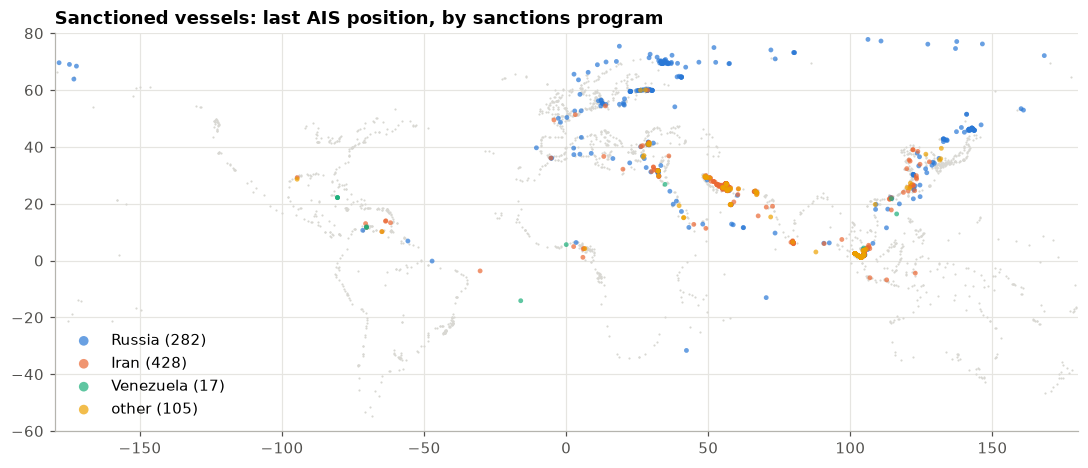

In [60]:
# Where were they last seen? One row per vessel: its most recent position.
seen = sql('''
    SELECT s.name, s.vessel_flag,
           CASE WHEN s.programs LIKE '%RUSSIA%' THEN 'Russia'
                WHEN s.programs LIKE '%IRAN%'   THEN 'Iran'
                WHEN s.programs LIKE '%VENEZUELA%' THEN 'Venezuela'
                ELSE 'other' END AS program,
           a.latitude, a.longitude, a.partition_date AS last_seen
    FROM sanctioned_vessels s
    JOIN ais_positions a USING (imo)
    WHERE a.latitude IS NOT NULL
    QUALIFY row_number() OVER (PARTITION BY s.imo ORDER BY a.partition_date DESC) = 1
''')
display(seen["program"].value_counts().rename("vessels").to_frame())

fig, ax = plt.subplots(figsize=(12, 6))
# The ports from section 4f, in light gray, stand in for a coastline.
ax.scatter(profiles["longitude"], profiles["latitude"], s=2, color="#d8d7d2", linewidths=0)
for program, color in zip(["Russia", "Iran", "Venezuela", "other"], [BLUE, ORANGE, AQUA, PALETTE[3]]):
    p = seen[seen["program"] == program]
    ax.scatter(p["longitude"], p["latitude"], s=10, color=color, alpha=0.7, edgecolor="none", label=f"{program} ({len(p)})")
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 80)
ax.set_aspect("equal")
ax.set_title("Sanctioned vessels: last AIS position, by sanctions program")
ax.legend(loc="lower left", markerscale=2)
plt.show()

About half of the sanctioned vessels (810 of 1,542 on 2026-10-07) show up in `ais_positions`, most of them under the Iran or Russia
programs. On the map they cluster in the Persian Gulf, in the Singapore Strait and off Malaysia (a known area for
ship-to-ship oil transfers), in the Baltic, around the Turkish straits, along China's coast and on Russia's Arctic coast.

Three cautions before reading more into it:
- A matching IMO number means the ship is on the list. It doesn't mean it is doing anything illegal at that position.
- The position comes from the ship's own AIS transmitter, which sanctioned ships are known to switch off or falsify.
- Our AIS sources cover some seas much better than others (section 6). A missing ship may just be out of coverage.

## 15. Where to go next

### Patterns to reuse

```python
# Any table, any query — result comes back as a pandas DataFrame
df = sql("SELECT ... FROM <table> WHERE ... GROUP BY ...")

# Prefer polars? Same query, different output
pl_df = con.sql("SELECT ...").pl()

# Querying the same slice many times? Copy it into memory once, then it's instant.
con.sql("CREATE OR REPLACE TABLE sg AS SELECT * FROM port_activity WHERE port_name = 'Singapore'")

# Save a result you want to keep (small results only)
df.to_parquet("my_result.parquet")

# Read a file at an older version of the dataset (HF keeps every commit)
con.sql(f"SELECT count(*) FROM 'hf://datasets/{REPO_ID}@<commit-sha>/ports/ports.parquet'")
```

### Exercises

1. **Your own port.** Pick a port from `port_weekly` and plot its weekly calls by vessel type, with a 13-week average.
2. **Saudi Arabia's way around Hormuz.** Section 5d shows Saudi Red Sea port calls rising after the closure.
   Plot weekly port calls for Yanbu and Jeddah through 2026 (`port_weekly`, filter on `port_name`). When did they
   peak, and what happened after the Houthi missile strikes on tankers off Yanbu on 5 and 24 August 2026?
3. **Panama Canal drought.** In 2023 low water levels cut Panama Canal transits. Use `chokepoint_daily` to find when it
   started, how deep the drop was, and when it recovered. (Hint: `n_total_vs_year_ago_pct`.)
4. **Disruptions.** Count `disruption_events` per year by `event_type` (EQ = earthquake, TC = tropical cyclone,
   FL = flood...). Remember to normalize `alert_level`.
5. **China's soybean share.** Using `us_export_sales`, compute China's share of US soybean exports per marketing year.
6. **Imports by mode.** `us_trade_partners` splits value into `vessel_value_usd` and `air_value_usd`. Which partners ship
   mostly by air?
7. **EU ports.** Explore `maritime_freight` (Eurostat). Start with `DESCRIBE` and `SUMMARIZE`, as in section 2.

8. **Air cargo.** Which US airport pairs carry the most freight in `air_cargo`? Many rows are passenger-only flights with
   `freight_pounds = 0`; filter them out first.
9. **Storm damage.** Total `damage_property_millions` per year in `storm_events`, by `event_type`. The distribution is
   very skewed (section 4e): compare the mean with the median, and find the single costliest events.
10. **Hormuz in the nowcast.** Repeat section 11's year-over-year chart for Kuwait (`iso3 = 'KWT'`) and Saudi Arabia (`'SAU'`).
    Does it show the same 2026 drop as JODI in 14a?

### Tables this notebook doesn't cover

| Table | Why it's left out |
|---|---|
| `chokepoint_transits` | The raw daily counts behind `chokepoint_daily` (section 5) |
| `curated_ais_positions` | Same rows as `ais_positions`; the columns it adds are mostly empty |
| `grain_export_destinations`, `grain_trade_monthly` | More derived grain tables: sales by buyer per week, Census monthly grain trade |
| `oil_inventories` | EIA weekly oil stocks; used only in the freshness check |
| `chokepoint_profiles`, `chokepoint_status` | Reference data and a daily status feed, under 100 rows each |
| `port_calls`, `curated_vessels` | Finnish waters only (Digitraffic) |
| `fuel_prices`, `weather`, `marine_weather` | Short daily snapshots, a few hundred rows or fewer |
| `port_metrics`, `trade_flow`, `maritime_freight` | Singapore port statistics and Eurostat trade and port data (`maritime_freight` is exercise 7) |
| `air_cargo`, `storm_events` | Exercises 8 and 9 |

### Docs

- DuckDB SQL: <https://duckdb.org/docs/sql/introduction> · reading from Hugging Face: <https://duckdb.org/docs/extensions/httpfs/hugging_face>
- pandas: <https://pandas.pydata.org/docs/user_guide/10min.html>
- matplotlib: <https://matplotlib.org/stable/tutorials/index> · seaborn: <https://seaborn.pydata.org/tutorial.html>